# 🌬️ Wind Turbine Anomaly Detection — CARE to Compare Dataset
### Enbridge Data Science Competition

**Objective:** Leverage SCADA time-series data to detect anomalies early in wind turbine operations, providing explainable and actionable insights that support predictive maintenance, minimize downtime, and contribute to more sustainable renewable energy systems.

**Coverage:** Both focus areas — Gearbox & Bearing Health + Thermal & Electrical Anomalies  
**Evaluation:** CARE Score (Coverage · Accuracy · Reliability · Earliness)

---

## Table of Contents
1. [Environment Setup](#1-environment-setup)
2. [Data Loading & Structure Exploration](#2-data-loading--structure-exploration)
3. [Data Cleaning & Preparation](#3-data-cleaning--preparation)
4. [Exploratory Data Analysis (EDA)](#4-exploratory-data-analysis-eda)
5. [Feature Engineering](#5-feature-engineering)
6. [Anomaly Detection — Unsupervised Baseline (Isolation Forest)](#6-anomaly-detection--unsupervised-baseline-isolation-forest)
7. [Anomaly Detection — Autoencoder (Deep Learning)](#7-anomaly-detection--autoencoder-deep-learning)
8. [Anomaly Detection — Statistical Process Control (SPC)](#8-anomaly-detection--statistical-process-control-spc)
9. [CARE Score Evaluation](#9-care-score-evaluation)
10. [Explainability & Feature Importance](#10-explainability--feature-importance)
11. [Actionable Recommendations & Monitoring Strategy](#11-actionable-recommendations--monitoring-strategy)
12. [Summary & Conclusions](#12-summary--conclusions)

---
## 1. Environment Setup

In [2]:
# ── Install dependencies (run once) ──────────────────────────────────────────
# Uncomment if needed:
# !pip install pandas numpy matplotlib seaborn scikit-learn torch tqdm joblib plotly

In [3]:
# ── Core imports ──────────────────────────────────────────────────────────────
import os
import glob
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from pathlib import Path
from tqdm import tqdm
import joblib

# ── Sklearn ───────────────────────────────────────────────────────────────────
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.decomposition import PCA
from sklearn.metrics import (precision_score, recall_score, f1_score,
                              roc_auc_score, confusion_matrix, ConfusionMatrixDisplay)
from sklearn.pipeline import Pipeline

# ── PyTorch (Autoencoder) ─────────────────────────────────────────────────────
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

# ── Plotly (interactive plots) ────────────────────────────────────────────────
import plotly.graph_objects as go
import plotly.express as px
from plotly.subplots import make_subplots

warnings.filterwarnings('ignore')
plt.rcParams.update({'figure.dpi': 120, 'font.size': 11})
sns.set_style('whitegrid')

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)

print('✅ All libraries loaded successfully.')
print(f'   PyTorch version : {torch.__version__}')
print(f'   CUDA available  : {torch.cuda.is_available()}')

✅ All libraries loaded successfully.
   PyTorch version : 2.10.0+cu128
   CUDA available  : True


In [4]:
# ── Path Configuration ────────────────────────────────────────────────────────
# !! UPDATE THIS to the root folder containing farms A/, B/, C/ !!
DATA_ROOT = Path('C:\\Users\\karan\\Documents\\dsmlc_final_comp\\CARE_To_Compare\\CARE_To_Compare')   # e.g. Path('C:/Users/you/Downloads/care_dataset')

# ── Farm folder name variants ────────────────────────────────────────────────
# Check your actual folder names — some distributions use 'Wind Farm A' style
# Common variants:
#   FARMS = ['A', 'B', 'C']               # short names
#   FARMS = ['Wind Farm A', 'Wind Farm B', 'Wind Farm C']  # full names
FARMS = ['Wind Farm A', 'Wind Farm B', 'Wind Farm C']  # adjust if needed


# Verify structure
for farm in FARMS:
    p = DATA_ROOT / farm
    status = '✅' if p.exists() else '❌ NOT FOUND'
    print(f'  Farm {farm}: {p}  {status}')

  Farm Wind Farm A: C:\Users\karan\Documents\dsmlc_final_comp\CARE_To_Compare\CARE_To_Compare\Wind Farm A  ✅
  Farm Wind Farm B: C:\Users\karan\Documents\dsmlc_final_comp\CARE_To_Compare\CARE_To_Compare\Wind Farm B  ✅
  Farm Wind Farm C: C:\Users\karan\Documents\dsmlc_final_comp\CARE_To_Compare\CARE_To_Compare\Wind Farm C  ✅


### 📋 Dataset Quick Reference (from CARE to Compare documentation)
| Farm | Type | Location | Events | Approx Rows | Sensor Columns | CSV Separator |
|------|------|----------|--------|-------------|----------------|--------------|
| A | Onshore | Portugal | 22 (12 anomaly, 10 normal) | ~1,196,747 | ~86 | **`;`** |
| B | Offshore | Germany | 15 | ~859,000 | ~257 | **`;`** |
| C | Offshore | Germany | TBC | TBC | TBC | **`;`** |

> ⚠️ **Critical:** All CSVs in this dataset use **semicolon (`;`)** as the separator, not comma. `pd.read_csv(..., sep=';')` is required everywhere.

> ℹ️ `event_id` in filenames is a string (e.g. `'42'`) but `event_info.csv` stores it as an integer. Always cast with `.astype(int)` before merging.

---
## 2. Data Loading & Structure Exploration

In [5]:
def load_event_info(farm: str) -> pd.DataFrame:
    path = DATA_ROOT / farm / 'event_info.csv'
    df = pd.read_csv(path, sep=';')   # must use semicolon for CARE dataset
    df['farm'] = farm
    return df

def load_feature_description(farm: str) -> pd.DataFrame:
    path = DATA_ROOT / farm / 'feature_description.csv'
    return pd.read_csv(path, sep=';')      # fix

def load_dataset(farm: str, event_id: str) -> pd.DataFrame:
    candidates = [
        DATA_ROOT / farm / 'datasets' / f'{event_id}.csv',
        DATA_ROOT / farm / f'{event_id}.csv',
    ]
    for path in candidates:
        if path.exists():
            df = pd.read_csv(path, sep=';') # fix also here
            df['farm'] = farm
            df['event_id'] = event_id
            return df
    raise FileNotFoundError(...)

# ── Load event info for all farms ────────────────────────────────────────────
events_list = []
for farm in FARMS:
    try:
        events_list.append(load_event_info(farm))
    except FileNotFoundError as e:
        print(f'  ⚠️  {e}')

events_df = pd.concat(events_list, ignore_index=True)
print(f'Total events loaded: {len(events_df)}')
print(f'Anomaly events    : {(events_df.event_label == "anomaly").sum()}')
print(f'Normal events     : {(events_df.event_label == "normal").sum()}')
events_df.head(10)

Total events loaded: 95
Anomaly events    : 45
Normal events     : 50


,asset,event_id,event_label,event_start,event_start_id,event_end,event_end_id,event_description,farm,asset_id
0,11.0,68,anomaly,2023-07-28 13:20:00,52063,2023-08-11 13:10:00,54076,Transformer failure,Wind Farm A,NaN
1,21.0,22,anomaly,2023-08-12 09:50:00,51888,2023-08-19 10:00:00,52892,Hydraulic group,Wind Farm A,NaN
2,21.0,72,anomaly,2023-10-10 08:40:00,52497,2023-10-17 08:40:00,53505,Gearbox failure,Wind Farm A,NaN
3,0.0,73,anomaly,2023-06-10 11:40:00,52745,2023-06-17 11:40:00,53753,Hydraulic group,Wind Farm A,NaN
4,0.0,0,anomaly,2023-08-06 06:10:00,52436,2023-08-20 06:10:00,54447,Generator bearing failure,Wind Farm A,NaN
5,0.0,26,anomaly,2023-10-12 10:20:00,52261,2023-10-19 10:20:00,53269,Hydraulic group,Wind Farm A,NaN
6,10.0,40,anomaly,2022-12-26 00:00:00,51363,2023-01-26 13:00:00,55870,Generator bearing failure,Wind Farm A,NaN
7,10.0,42,anomaly,2023-09-09 15:50:00,52303,2023-09-16 15:50:00,53309,Hydraulic group,Wind Farm A,NaN
8,10.0,10,anomaly,2023-10-11 08:40:00,52611,2023-10-18 08:40:00,53591,Gearbox failure,Wind Farm A,NaN
9,13.0,45,anomaly,2023-04-19 18:10:00,52731,2023-04-26 18:10:00,53738,Hydraulic group,Wind Farm A,NaN


In [6]:
# ── Load feature descriptions ─────────────────────────────────────────────────
feat_desc = {}
for farm in FARMS:
    try:
        feat_desc[farm] = load_feature_description(farm)
        print(f'Farm {farm}: {len(feat_desc[farm])} sensor descriptions')
    except FileNotFoundError as e:
        print(f'  ⚠️  {e}')

# Show sample
if 'A' in feat_desc:
    display(feat_desc['A'].head(10))

Farm Wind Farm A: 54 sensor descriptions
Farm Wind Farm B: 63 sensor descriptions
Farm Wind Farm C: 238 sensor descriptions


In [7]:
# ── Load a sample of datasets (memory-safe) ───────────────────────────────────
# Strategy: load a representative balanced sample — not all 95 datasets at once.
# We pick up to MAX_PER_LABEL events per label per farm to stay memory-efficient.

MAX_PER_LABEL = 4   # Increase if your RAM allows (≥32GB recommended for 8+)

events_df = pd.concat([load_event_info(farm) for farm in FARMS], ignore_index=True)
print(events_df.columns)
print(events_df[['farm','event_label']].head())

MAX_PER_LABEL = 4

sample_events = (
    events_df
    .groupby(['farm', 'event_label'], group_keys=False)
    .sample(n=MAX_PER_LABEL, random_state=RANDOM_SEED)
    .reset_index(drop=True)
)

print("columns:", sample_events.columns.tolist())
print(sample_events.head())

Index(['asset', 'event_id', 'event_label', 'event_start', 'event_start_id',
       'event_end', 'event_end_id', 'event_description', 'farm', 'asset_id'],
      dtype='str')
          farm event_label
0  Wind Farm A     anomaly
1  Wind Farm A     anomaly
2  Wind Farm A     anomaly
3  Wind Farm A     anomaly
4  Wind Farm A     anomaly
columns: ['asset', 'event_id', 'event_label', 'event_start', 'event_start_id', 'event_end', 'event_end_id', 'event_description', 'farm', 'asset_id']
   asset  event_id event_label          event_start  event_start_id  \
0   13.0        84     anomaly  2023-09-05 15:30:00           52623   
1   13.0        45     anomaly  2023-04-19 18:10:00           52731   
2   11.0        68     anomaly  2023-07-28 13:20:00           52063   
3   10.0        10     anomaly  2023-10-11 08:40:00           52611   
4   11.0        25      normal  2023-05-23 06:50:00           52289   

             event_end  event_end_id    event_description         farm  \
0  2023-09-12 1

In [8]:
# ── Load SCADA data for sampled events ───────────────────────────────────────
raw_frames = []
failed = []

for _, row in tqdm(sample_events.iterrows(), total=len(sample_events), desc='Loading CSVs'):
    try:
        df = load_dataset(row['farm'], str(row['event_id']))
        df['event_label'] = row['event_label']
        df['event_description'] = row.get('event_description', '')
        raw_frames.append(df)
    except FileNotFoundError as e:
        failed.append(str(e))

if failed:
    print(f'\n⚠️  {len(failed)} datasets not found (check DATA_ROOT path):')
    for f in failed[:5]:
        print(f'   {f}')

raw_df = pd.concat(raw_frames, ignore_index=True)
print(f'\n✅ Loaded {len(raw_df):,} rows × {raw_df.shape[1]} columns')
raw_df.head(3)

Loading CSVs: 100%|██████████| 24/24 [00:26<00:00,  1.12s/it]



✅ Loaded 1,325,672 rows × 1030 columns


,time_stamp,asset_id,id,train_test,status_type_id,sensor_0_avg,sensor_1_avg,sensor_2_avg,wind_speed_3_avg,wind_speed_4_avg,...,wind_speed_236_min,wind_speed_236_std,wind_speed_235_avg,wind_speed_235_max,wind_speed_235_min,wind_speed_235_std,wind_speed_237_avg,wind_speed_237_max,wind_speed_237_min,wind_speed_237_std
0,2022-09-03 15:30:00,13,0,train,0,31.0,81.6,-2.2,13.5,13.4,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2022-09-03 15:40:00,13,1,train,0,31.0,89.8,13.3,13.1,12.8,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2022-09-03 15:50:00,13,2,train,0,31.0,68.7,-6.7,13.3,13.2,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


---
## 3. Data Cleaning & Preparation

In [9]:
# ── 3.1  Column categorisation ────────────────────────────────────────────────
META_COLS = ['time_stamp', 'asset_id', 'id', 'train_test',
             'status_type_id', 'farm', 'event_id', 'event_label', 'event_description']

sensor_cols = [c for c in raw_df.columns if c not in META_COLS]
avg_cols    = [c for c in sensor_cols if c.endswith('_avg')]
print(f'Total sensor columns : {len(sensor_cols)}')
print(f'  _avg features      : {len(avg_cols)}')
print(f'  other stats        : {len(sensor_cols) - len(avg_cols)}')

Total sensor columns : 1021
  _avg features      : 254
  other stats        : 767


In [10]:
# ── 3.2  Parse timestamps ─────────────────────────────────────────────────────
raw_df['time_stamp'] = pd.to_datetime(raw_df['time_stamp'])
raw_df = raw_df.sort_values(['event_id', 'time_stamp']).reset_index(drop=True)
print('Time range per event (sample):')
raw_df.groupby('event_id')['time_stamp'].agg(['min', 'max', 'count']).head(6)

Time range per event (sample):


,min,max,count
event_id,,,
10,2022-10-09 08:40:00,2023-10-18 08:40:00,53592
14,2022-03-03 14:00:00,2023-03-16 18:40:00,54197
16,2022-12-23 00:00:00,2024-01-07 23:50:00,53568
18,2022-09-11 00:00:00,2023-09-22 23:50:00,52848
19,2022-02-02 00:00:00,2023-02-28 00:00:00,56274
21,2022-09-22 20:10:00,2023-10-01 20:10:00,53514


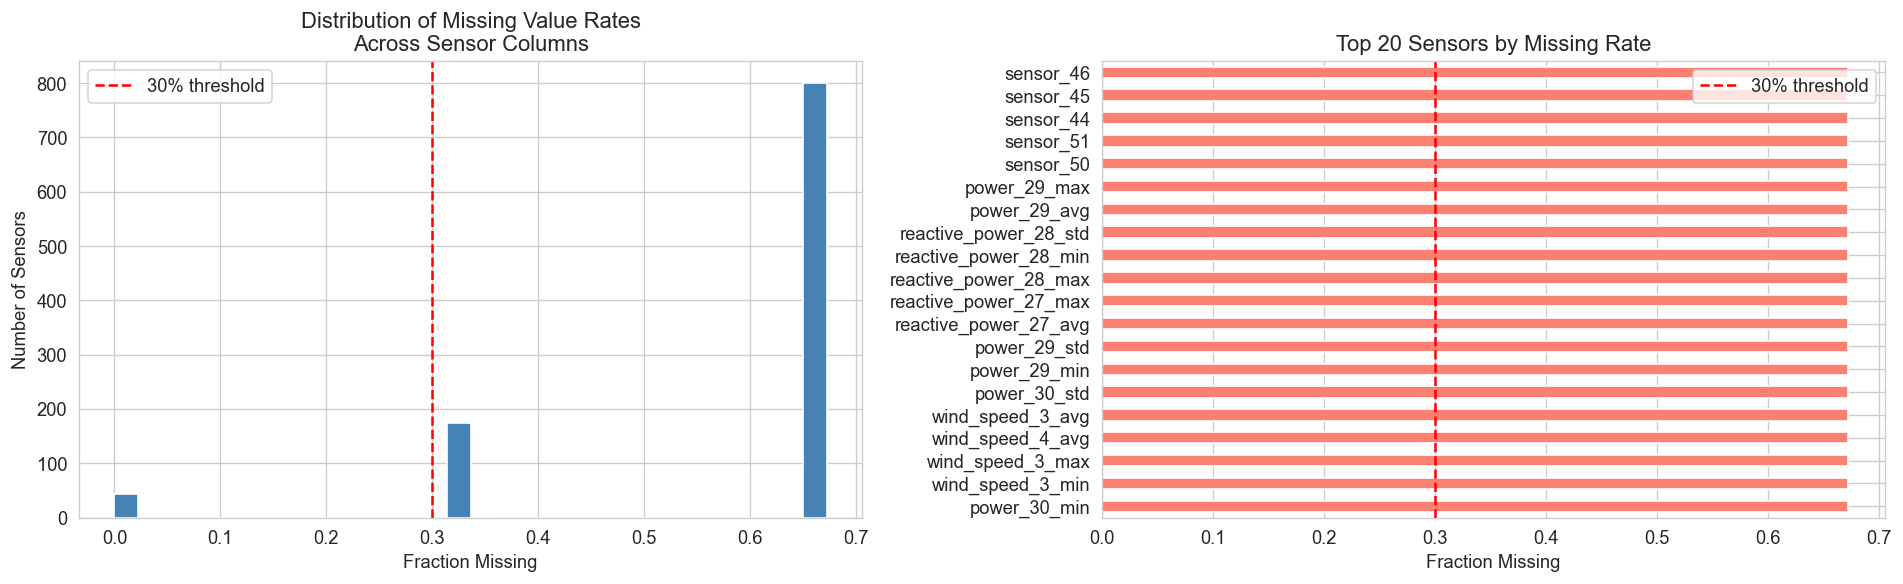

Sensors with >30% missing: 977 → will be dropped


In [11]:
# ── 3.3  Missing value analysis ───────────────────────────────────────────────
miss = raw_df[sensor_cols].isnull().mean().sort_values(ascending=False)
high_miss = miss[miss > 0.30]

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Distribution of missing rates
axes[0].hist(miss.values, bins=30, color='steelblue', edgecolor='white')
axes[0].axvline(0.30, color='red', linestyle='--', label='30% threshold')
axes[0].set_title('Distribution of Missing Value Rates\nAcross Sensor Columns')
axes[0].set_xlabel('Fraction Missing')
axes[0].set_ylabel('Number of Sensors')
axes[0].legend()

# Top 20 highest missing
miss.head(20).plot(kind='barh', ax=axes[1], color='salmon')
axes[1].axvline(0.30, color='red', linestyle='--', label='30% threshold')
axes[1].set_title('Top 20 Sensors by Missing Rate')
axes[1].set_xlabel('Fraction Missing')
axes[1].legend()

plt.tight_layout()
plt.savefig('fig_missing_values.png', bbox_inches='tight')
plt.show()

print(f'Sensors with >30% missing: {len(high_miss)} → will be dropped')

In [12]:
# ── 3.4  Drop high-missingness sensors & impute remaining ─────────────────────
drop_sensors = high_miss.index.tolist()
raw_df.drop(columns=drop_sensors, inplace=True)

# Update sensor list
sensor_cols = [c for c in raw_df.columns if c not in META_COLS]
avg_cols    = [c for c in sensor_cols if c.endswith('_avg')]

# Forward-fill within each event (preserves time-series continuity), then back-fill
raw_df[sensor_cols] = (
    raw_df.groupby('event_id')[sensor_cols]
    .transform(lambda x: x.ffill().bfill())
)

remaining_miss = raw_df[sensor_cols].isnull().sum().sum()
print(f'Remaining missing values after imputation: {remaining_miss}')
print(f'Working sensor columns: {len(sensor_cols)} ({len(avg_cols)} are _avg)')

Remaining missing values after imputation: 0
Working sensor columns: 44 (35 are _avg)


In [13]:
print("Columns in raw_df:")
print(raw_df.columns.tolist())
print("\nFirst few rows:")
print(raw_df.head())
print("\nData types:")
print(raw_df.dtypes)

Columns in raw_df:
['time_stamp', 'asset_id', 'id', 'train_test', 'status_type_id', 'sensor_0_avg', 'sensor_1_avg', 'sensor_7_avg', 'sensor_8_avg', 'sensor_9_avg', 'sensor_10_avg', 'sensor_12_avg', 'sensor_13_avg', 'sensor_14_avg', 'sensor_15_avg', 'sensor_16_avg', 'sensor_18_avg', 'sensor_18_max', 'sensor_18_min', 'sensor_18_std', 'sensor_19_avg', 'sensor_20_avg', 'sensor_21_avg', 'sensor_22_avg', 'sensor_23_avg', 'sensor_24_avg', 'sensor_25_avg', 'sensor_26_avg', 'sensor_31_avg', 'sensor_31_max', 'sensor_31_min', 'sensor_31_std', 'sensor_32_avg', 'sensor_33_avg', 'sensor_34_avg', 'sensor_35_avg', 'sensor_36_avg', 'sensor_37_avg', 'sensor_38_avg', 'sensor_39_avg', 'sensor_40_avg', 'sensor_41_avg', 'sensor_42_avg', 'sensor_43_avg', 'sensor_52_avg', 'sensor_52_max', 'sensor_52_min', 'sensor_52_std', 'sensor_53_avg', 'farm', 'event_id', 'event_label', 'event_description']

First few rows:
           time_stamp  asset_id  id train_test  status_type_id  sensor_0_avg  \
0 2022-10-09 08:40:0

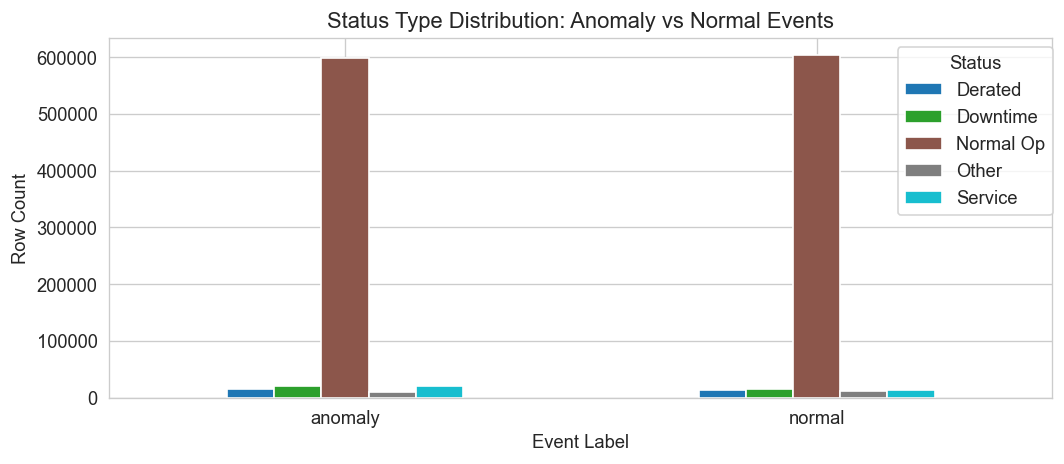

Rows kept for ML (status 0/1/2/5): 1,255,660 of 1,325,672


In [14]:
# ── 3.5  Status-type filtering & labelling ────────────────────────────────────
# Status 0 = Normal Operation, 2 = Idling → legitimate training data
# Status 3 = Service, 4 = Downtime → exclude from ML training to avoid leakage

STATUS_LABELS = {0: 'Normal Op', 1: 'Derated', 2: 'Idling',
                 3: 'Service',   4: 'Downtime', 5: 'Other'}
raw_df['status_label'] = raw_df['status_type_id'].map(STATUS_LABELS)

fig, ax = plt.subplots(figsize=(9, 4))
cnt = raw_df.groupby(['event_label', 'status_label']).size().unstack(fill_value=0)
cnt.plot(kind='bar', ax=ax, colormap='tab10', edgecolor='white')
ax.set_title('Status Type Distribution: Anomaly vs Normal Events')
ax.set_xlabel('Event Label')
ax.set_ylabel('Row Count')
ax.tick_params(axis='x', rotation=0)
ax.legend(title='Status', bbox_to_anchor=(1.01, 1))
plt.tight_layout()
plt.savefig('fig_status_distribution.png', bbox_inches='tight')
plt.show()

# Keep only valid operational rows for modelling
ml_df = raw_df[raw_df['status_type_id'].isin([0, 1, 2, 5])].copy()
print(f'Rows kept for ML (status 0/1/2/5): {len(ml_df):,} of {len(raw_df):,}')

In [15]:
# Keep only valid operational rows for modelling
ml_df = raw_df[raw_df['status_type_id'].isin([0, 1, 2, 5])].copy()
print(f'Rows kept for ML (status 0/1/2/5): {len(ml_df):,} of {len(raw_df):,}')

Rows kept for ML (status 0/1/2/5): 1,255,660 of 1,325,672


---
## 4. Exploratory Data Analysis (EDA)

In [16]:
# Explore feature descriptions for all farms
for farm in FARMS:
    print(f'\n{"="*60}')
    print(f'{farm}')
    print(f'{"="*60}')
    print(feat_desc[farm].head(20))
    print(f'\nColumn names: {feat_desc[farm].columns.tolist()}')


Wind Farm A
     sensor_name                  statistics_type  \
0       sensor_0                          average   
1       sensor_1                          average   
2       sensor_2                          average   
3   wind_speed_3  maximum,minimum,average,std_dev   
4   wind_speed_4                          average   
5       sensor_5  maximum,minimum,std_dev,average   
6       sensor_6                          average   
7       sensor_7                          average   
8       sensor_8                          average   
9       sensor_9                          average   
10     sensor_10                          average   
11     sensor_11                          average   
12     sensor_12                          average   
13     sensor_13                          average   
14     sensor_14                          average   
15     sensor_15                          average   
16     sensor_16                          average   
17     sensor_17                 

In [17]:
# Search for power-related sensors in Farm A
power_rows = feat_desc['Wind Farm A'][
    feat_desc['Wind Farm A'].iloc[:, 1].str.contains('power|active|kw', case=False, na=False)
]
print("Power sensors:")
print(power_rows)

# Search for wind/speed-related sensors
wind_rows = feat_desc['Wind Farm A'][
    feat_desc['Wind Farm A'].iloc[:, 1].str.contains('wind|speed|rpm|rotor', case=False, na=False)
]
print("\nWind/Speed sensors:")
print(wind_rows)

Power sensors:
Empty DataFrame
Columns: [sensor_name, statistics_type, description, unit, is_angle, is_counter]
Index: []

Wind/Speed sensors:
Empty DataFrame
Columns: [sensor_name, statistics_type, description, unit, is_angle, is_counter]
Index: []


In [18]:
# Try Farm B columns first, fall back to Farm A wind speed
try:
    POWER_COL = 'sensor_3_avg'
    WIND_COL = 'sensor_6_avg'
    # Verify they exist
    _ = ml_df[[POWER_COL, WIND_COL]]
except KeyError:
    POWER_COL = 'sensor_0_avg'
    WIND_COL = 'wind_speed_3_avg'
    
print(f'Using POWER_COL = {POWER_COL}')
print(f'Using WIND_COL = {WIND_COL}')

Using POWER_COL = sensor_0_avg
Using WIND_COL = wind_speed_3_avg


In [19]:
# Check which farms are in your data
print("Farms in ml_df:", ml_df['farm'].unique())

# Look at available columns
print("\nAvailable sensor columns (first 30):")
print([c for c in ml_df.columns if c.endswith('_avg')][:30])

Farms in ml_df: <StringArray>
['Wind Farm A', 'Wind Farm C', 'Wind Farm B']
Length: 3, dtype: str

Available sensor columns (first 30):
['sensor_0_avg', 'sensor_1_avg', 'sensor_7_avg', 'sensor_8_avg', 'sensor_9_avg', 'sensor_10_avg', 'sensor_12_avg', 'sensor_13_avg', 'sensor_14_avg', 'sensor_15_avg', 'sensor_16_avg', 'sensor_18_avg', 'sensor_19_avg', 'sensor_20_avg', 'sensor_21_avg', 'sensor_22_avg', 'sensor_23_avg', 'sensor_24_avg', 'sensor_25_avg', 'sensor_26_avg', 'sensor_31_avg', 'sensor_32_avg', 'sensor_33_avg', 'sensor_34_avg', 'sensor_35_avg', 'sensor_36_avg', 'sensor_37_avg', 'sensor_38_avg', 'sensor_39_avg', 'sensor_40_avg']


In [20]:
# ── 4.1  Power curve analysis (active power vs wind speed proxy) ──────────────
# Since farm-specific columns were dropped due to >30% missing values, use available proxies

POWER_COL = 'sensor_18_avg'   # Generator rpm (Farm A) — correlates with power output
WIND_COL  = 'sensor_0_avg'    # Fallback — use first available sensor

# Verify they exist and have variance
if POWER_COL in ml_df.columns and ml_df[POWER_COL].std() > 0:
    print(f'✅ Using POWER_COL = {POWER_COL}')
else:
    POWER_COL = 'sensor_1_avg'
    
if WIND_COL in ml_df.columns and ml_df[WIND_COL].std() > 0:
    print(f'✅ Using WIND_COL = {WIND_COL}')

print(f'Note: True wind speed not available across all 3 farms.')
print(f'Power curve will show generator RPM vs ambient conditions.')

✅ Using POWER_COL = sensor_18_avg
✅ Using WIND_COL = sensor_0_avg
Note: True wind speed not available across all 3 farms.
Power curve will show generator RPM vs ambient conditions.


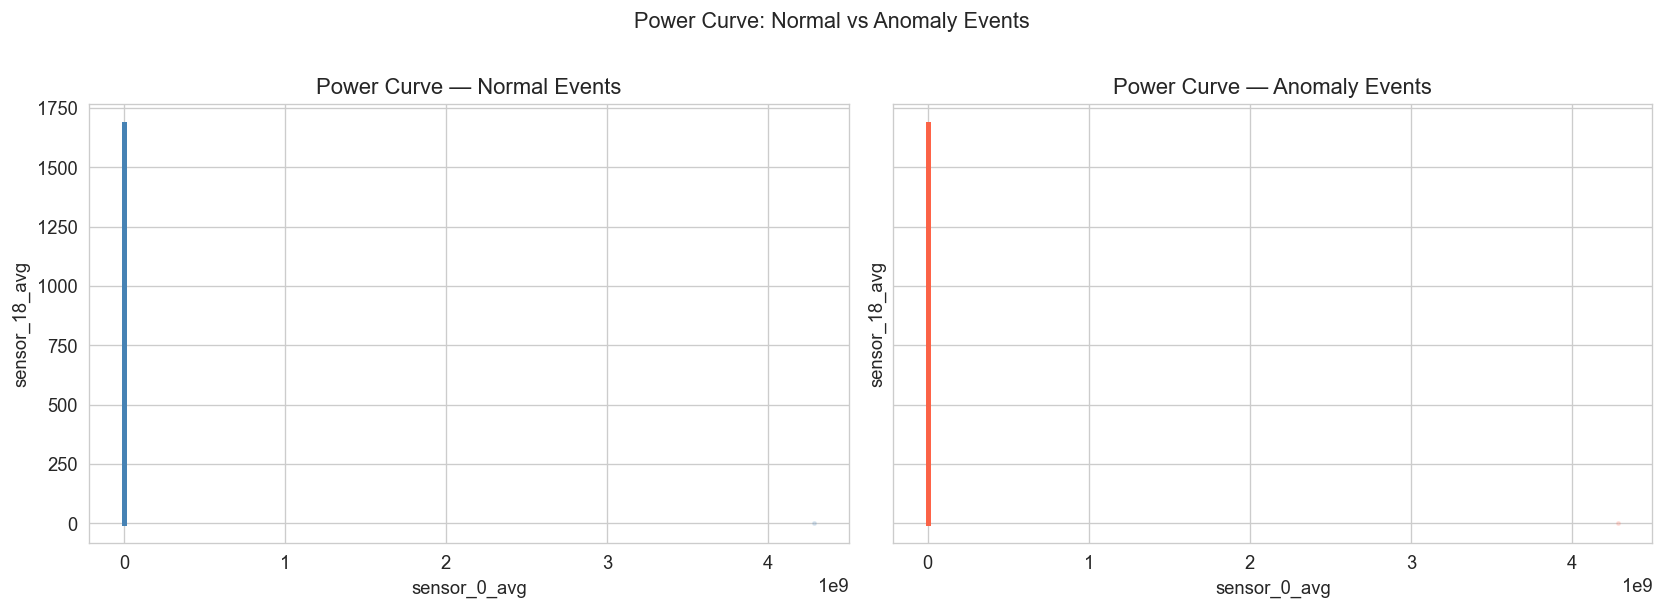

In [21]:
# ── 4.2  Power curve scatter — Normal vs Anomaly ─────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

for ax, label, color in zip(axes, ['normal', 'anomaly'], ['steelblue', 'tomato']):
    sub = ml_df[ml_df['event_label'] == label]
    ax.scatter(sub[WIND_COL], sub[POWER_COL],
               alpha=0.15, s=4, color=color, rasterized=True)
    ax.set_title(f'Power Curve — {label.capitalize()} Events')
    ax.set_xlabel(f'{WIND_COL}')
    ax.set_ylabel(f'{POWER_COL}')

plt.suptitle('Power Curve: Normal vs Anomaly Events', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('fig_power_curve.png', bbox_inches='tight')
plt.show()

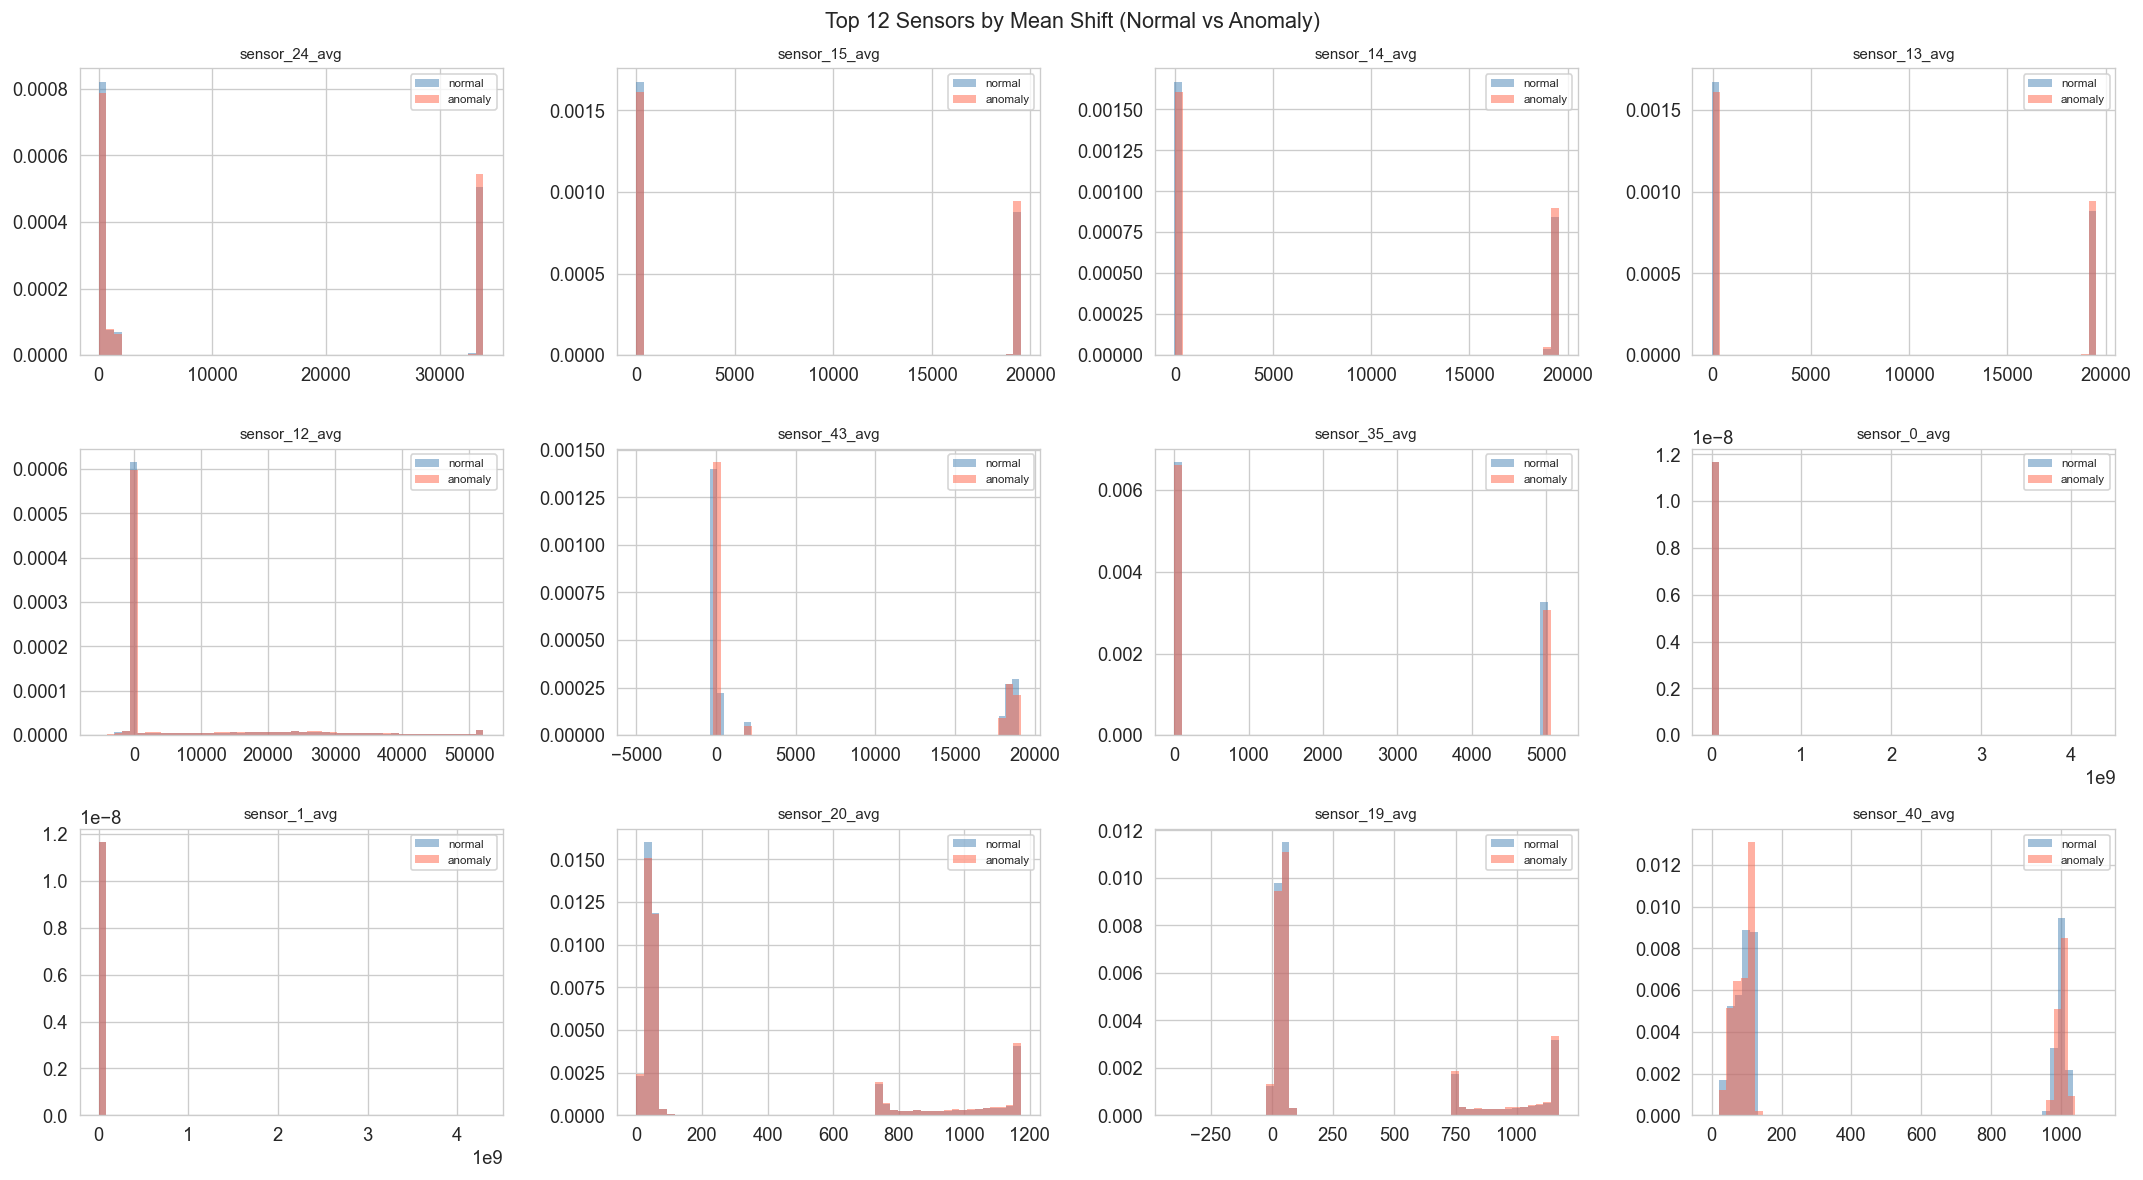

In [22]:
# ── 4.3  Sensor distribution comparison: Normal vs Anomaly ───────────────────
# Focus on _avg sensors; pick the top-N by absolute mean difference

N_FEATURES_PLOT = 12

norm_means = ml_df[ml_df['event_label'] == 'normal'][avg_cols].mean()
anom_means = ml_df[ml_df['event_label'] == 'anomaly'][avg_cols].mean()

diff = (anom_means - norm_means).abs().dropna().sort_values(ascending=False)
top_diff_cols = diff.head(N_FEATURES_PLOT).index.tolist()

fig, axes = plt.subplots(3, 4, figsize=(18, 10))
axes = axes.flatten()

for i, col in enumerate(top_diff_cols):
    for label, color in [('normal', 'steelblue'), ('anomaly', 'tomato')]:
        vals = ml_df[ml_df['event_label'] == label][col].dropna()
        axes[i].hist(vals, bins=50, alpha=0.5, color=color,
                     label=label, density=True, edgecolor='none')
    axes[i].set_title(col, fontsize=9)
    axes[i].legend(fontsize=7)

plt.suptitle(f'Top {N_FEATURES_PLOT} Sensors by Mean Shift (Normal vs Anomaly)', fontsize=13)
plt.tight_layout()
plt.savefig('fig_sensor_distributions.png', bbox_inches='tight')
plt.show()

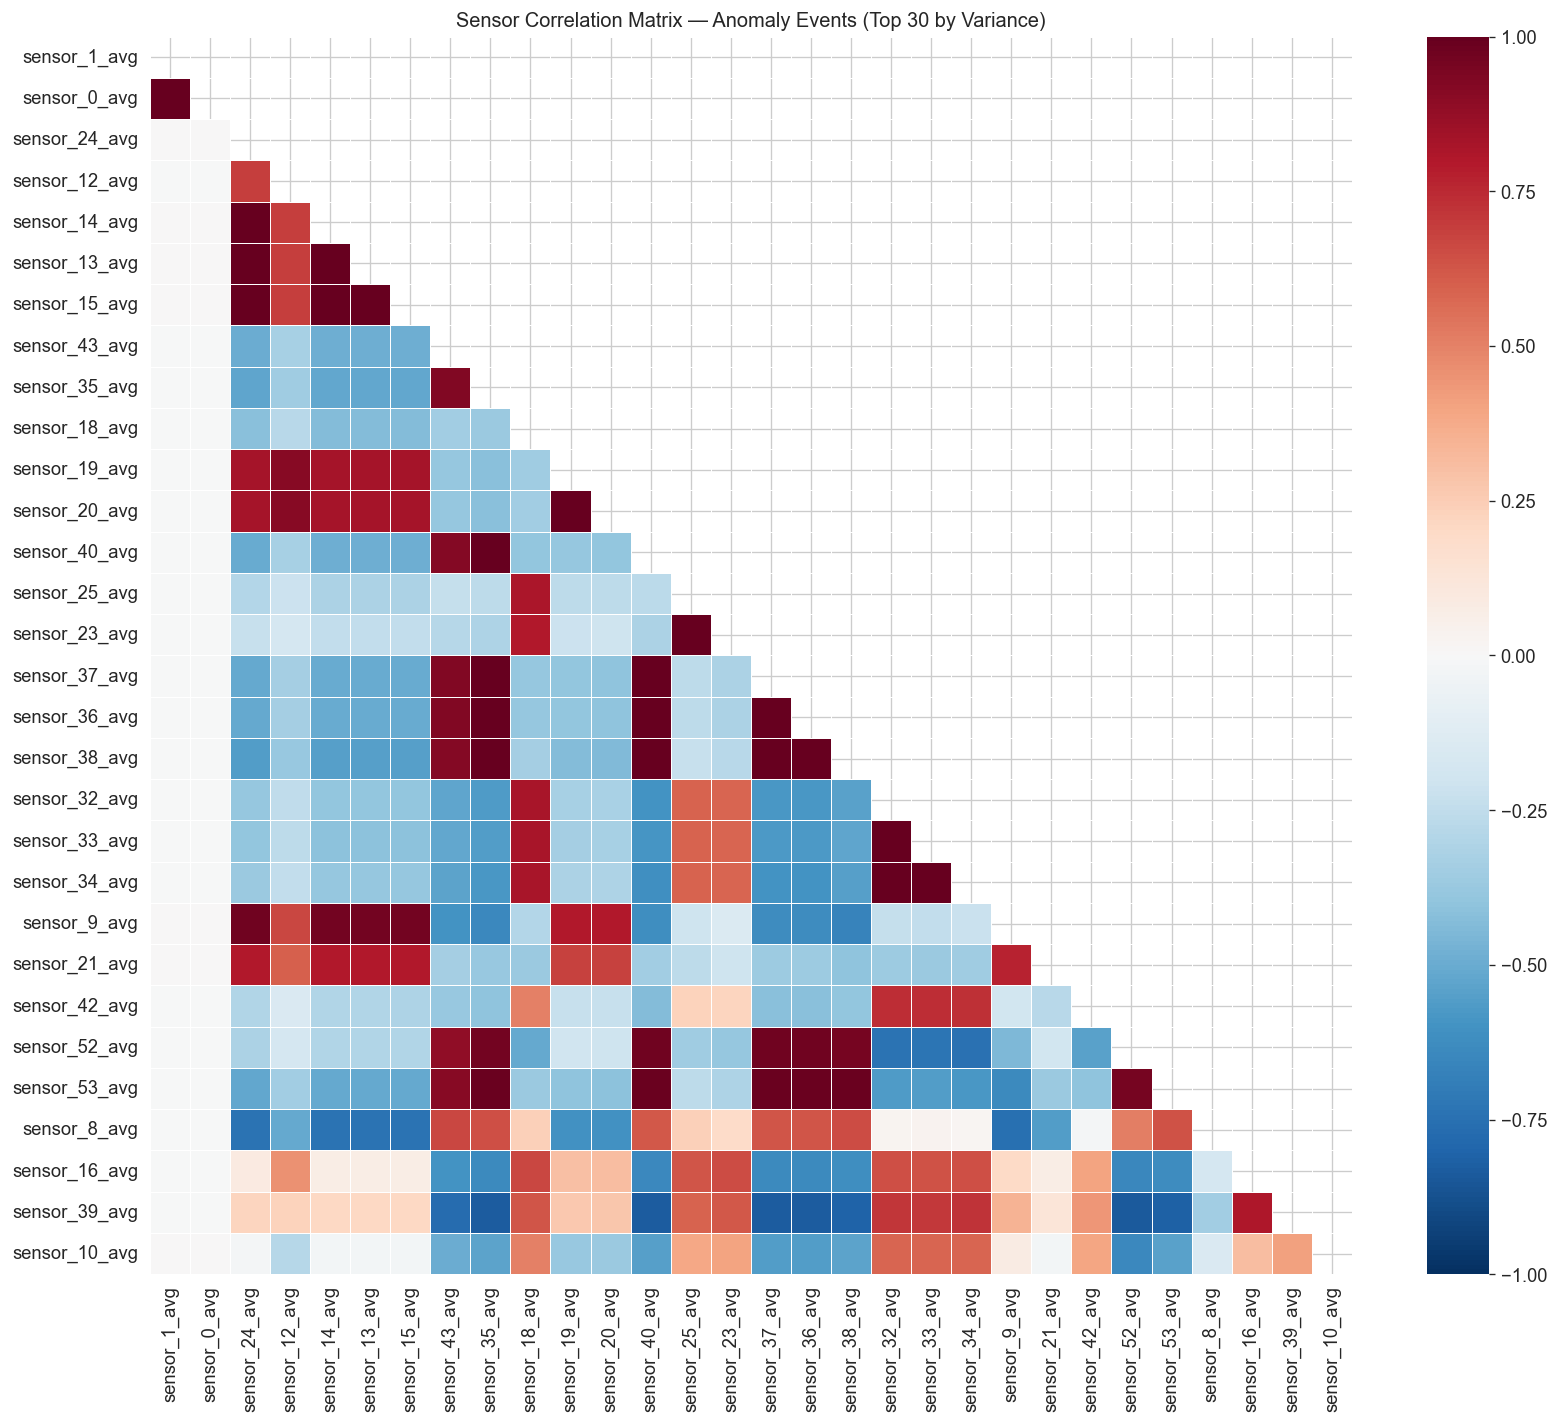

In [23]:
# ── 4.4  Correlation heatmap (avg sensors, anomaly events only) ───────────────
anom_data = ml_df[ml_df['event_label'] == 'anomaly'][avg_cols].dropna(axis=1)

# Keep only sensors with enough variance
low_var = anom_data.std()[anom_data.std() < 1e-6].index
anom_data = anom_data.drop(columns=low_var)

# Limit to top-30 sensors by variance for readability
top_var_cols = anom_data.var().sort_values(ascending=False).head(30).index
corr = anom_data[top_var_cols].corr()

fig, ax = plt.subplots(figsize=(14, 12))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, cmap='RdBu_r', center=0,
            annot=False, linewidths=0.3, ax=ax, vmin=-1, vmax=1)
ax.set_title('Sensor Correlation Matrix — Anomaly Events (Top 30 by Variance)', fontsize=12)
plt.tight_layout()
plt.savefig('fig_correlation_heatmap.png', bbox_inches='tight')
plt.show()

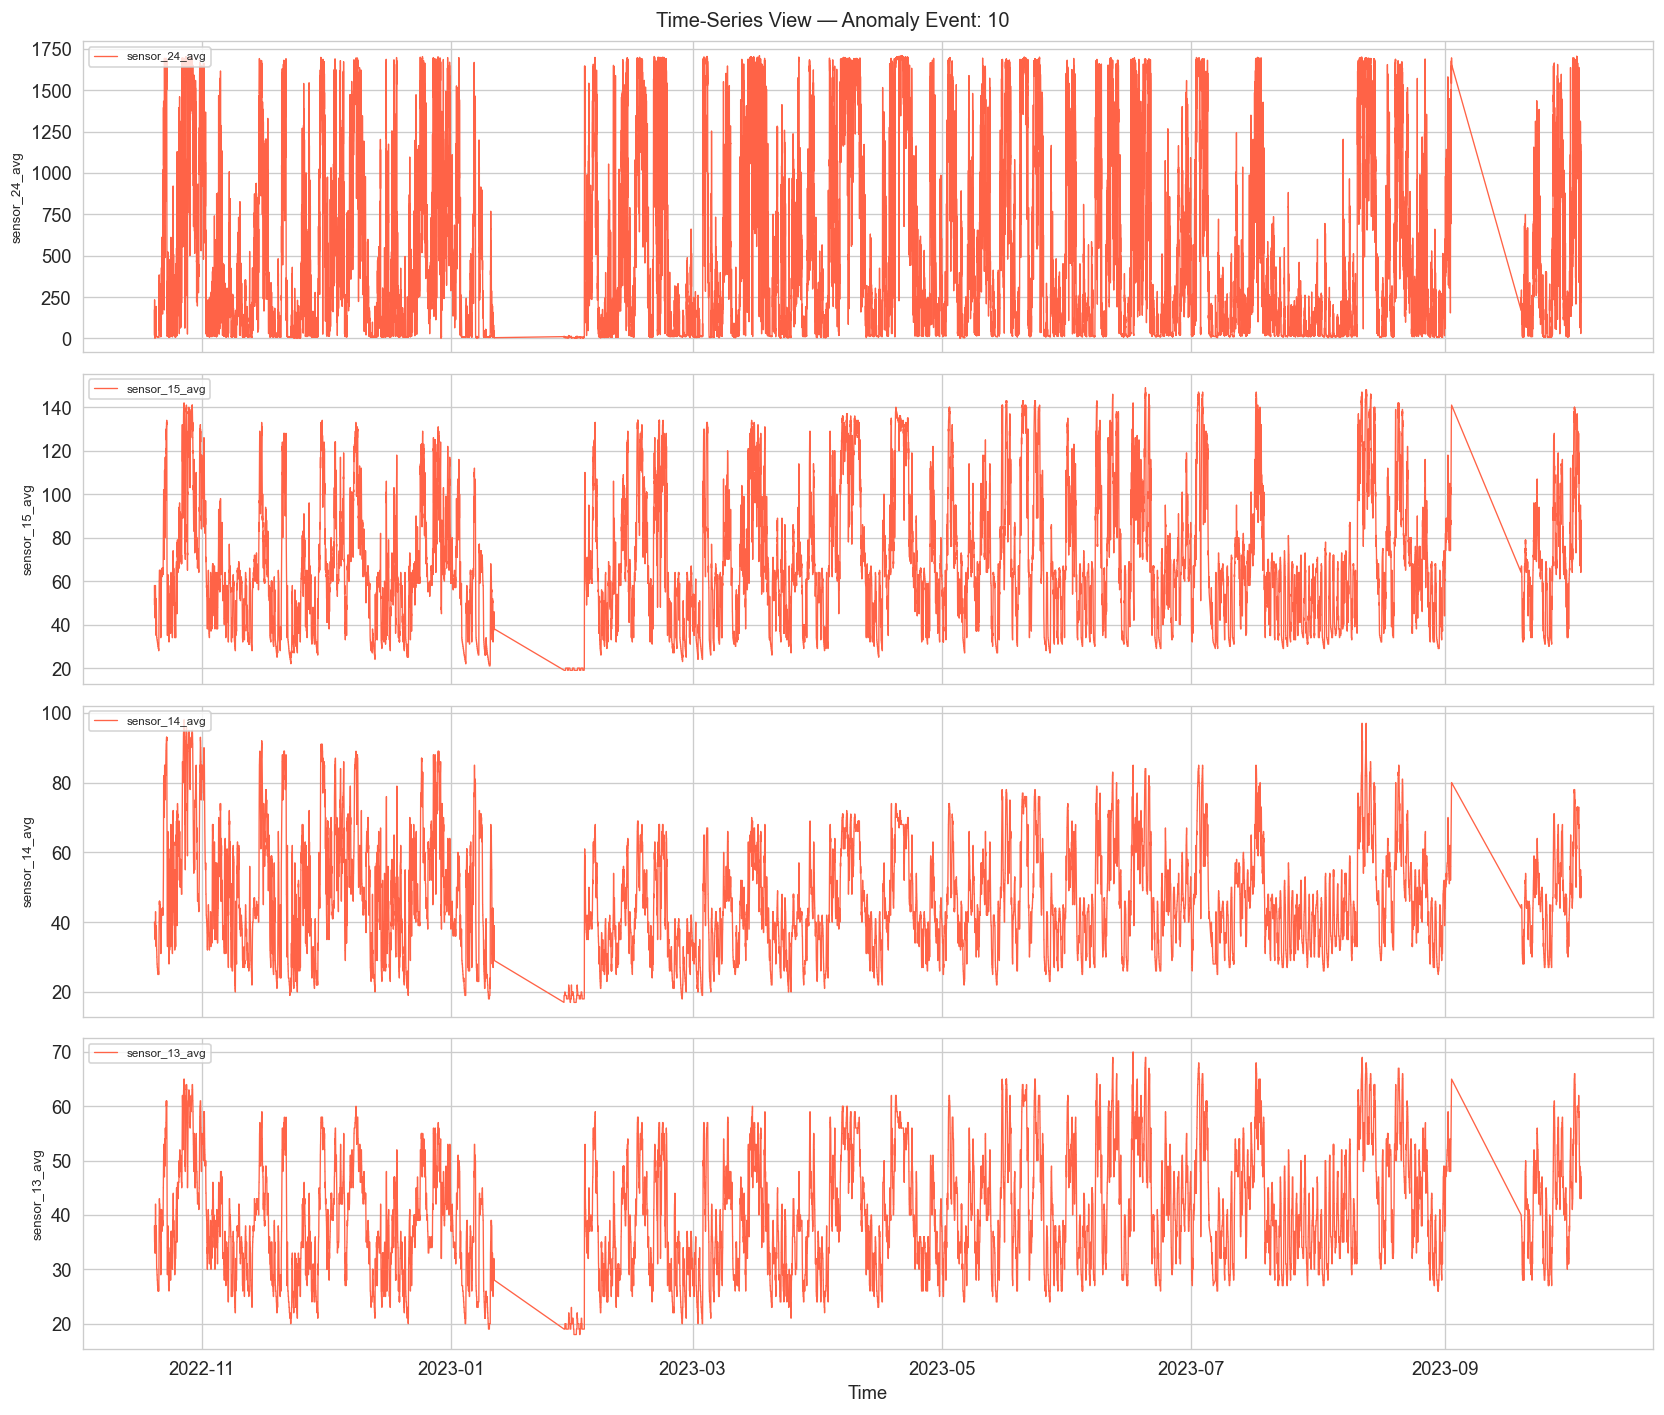

In [57]:
# ── 4.5  Time-series view of a sample anomaly event ──────────────────────────
sample_anom_id = ml_df[ml_df['event_label'] == 'anomaly']['event_id'].iloc[0]
sample_anom    = ml_df[ml_df['event_id'] == sample_anom_id].sort_values('time_stamp')

plot_cols = top_diff_cols[:4]   # Show top 4 most discriminating sensors

fig, axes = plt.subplots(len(plot_cols), 1, figsize=(14, 3 * len(plot_cols)), sharex=True)
if len(plot_cols) == 1:
    axes = [axes]

for ax, col in zip(axes, plot_cols):
    ax.plot(sample_anom['time_stamp'], sample_anom[col],
            lw=0.8, color='tomato', label=col)
    ax.set_ylabel(col, fontsize=8)
    ax.legend(loc='upper left', fontsize=7)

axes[-1].set_xlabel('Time')
plt.suptitle(f'Time-Series View — Anomaly Event: {sample_anom_id}', fontsize=12)
plt.tight_layout()
plt.savefig('fig_timeseries_anomaly.png', bbox_inches='tight')
plt.show()

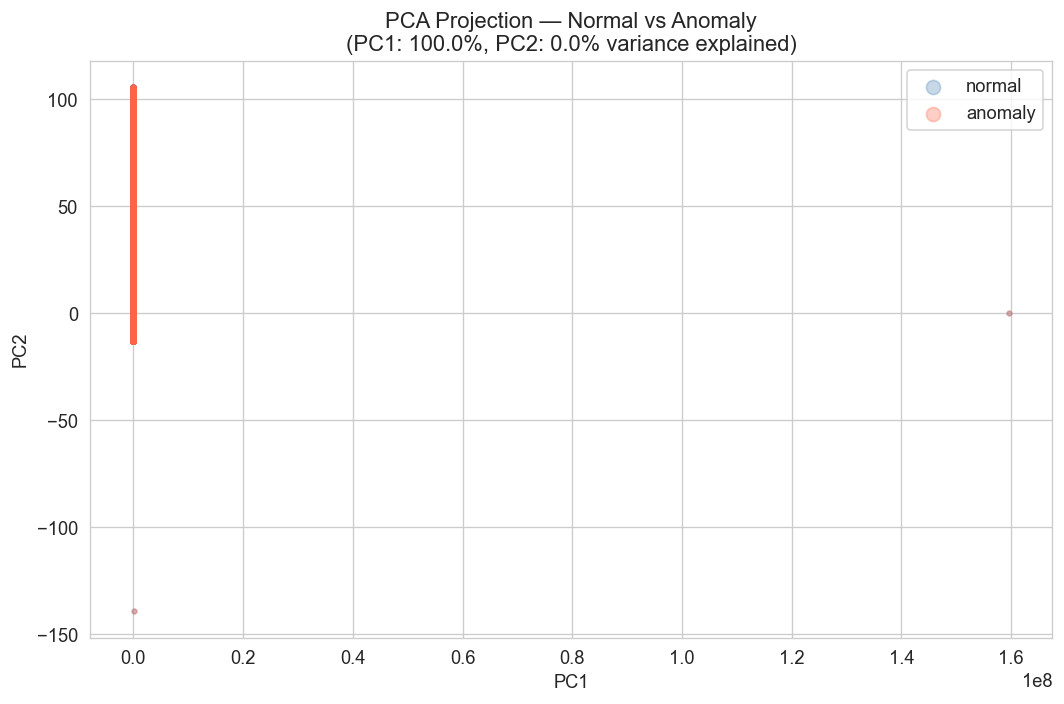

In [24]:
# ── 4.6  PCA visualisation: Normal vs Anomaly in 2D ──────────────────────────
pca_data = ml_df[avg_cols].copy()
pca_data = pca_data.fillna(pca_data.median())

scaler_pca = RobustScaler()
X_scaled   = scaler_pca.fit_transform(pca_data)

pca = PCA(n_components=2, random_state=RANDOM_SEED)
X_pca = pca.fit_transform(X_scaled)

labels = ml_df['event_label'].values
colors = np.where(labels == 'anomaly', 'tomato', 'steelblue')

fig, ax = plt.subplots(figsize=(9, 6))
for label, color in [('normal', 'steelblue'), ('anomaly', 'tomato')]:
    mask = labels == label
    ax.scatter(X_pca[mask, 0], X_pca[mask, 1],
               c=color, alpha=0.3, s=8, label=label, rasterized=True)

ax.set_title(f'PCA Projection — Normal vs Anomaly\n'
             f'(PC1: {pca.explained_variance_ratio_[0]:.1%}, '
             f'PC2: {pca.explained_variance_ratio_[1]:.1%} variance explained)')
ax.set_xlabel('PC1')
ax.set_ylabel('PC2')
ax.legend(markerscale=3)
plt.tight_layout()
plt.savefig('fig_pca.png', bbox_inches='tight')
plt.show()

---
## 5. Feature Engineering

In [25]:
# ── 5.1  Rolling statistics (within each event, time-ordered) ─────────────────
# Rolling mean and std over 6 steps = 1 hour of 10-min data

ROLL_WINDOW = 6   # 1-hour window

def add_rolling_features(df: pd.DataFrame, cols: list, window: int) -> pd.DataFrame:
    df = df.sort_values(['event_id', 'time_stamp'])
    grouped = df.groupby('event_id')
    roll_mean = grouped[cols].transform(lambda x: x.rolling(window, min_periods=1).mean())
    roll_std  = grouped[cols].transform(lambda x: x.rolling(window, min_periods=1).std().fillna(0))
    roll_mean.columns = [c + f'_roll{window}m' for c in cols]
    roll_std.columns  = [c + f'_roll{window}s' for c in cols]
    return pd.concat([df.reset_index(drop=True),
                      roll_mean.reset_index(drop=True),
                      roll_std.reset_index(drop=True)], axis=1)

# Use only a subset of avg cols to keep memory manageable
FEATURE_COLS = top_diff_cols   # top discriminating features from EDA

ml_df = add_rolling_features(ml_df, FEATURE_COLS, ROLL_WINDOW)
print(f'Shape after rolling features: {ml_df.shape}')

Shape after rolling features: (1255660, 78)


In [26]:
# ── 5.2  Residuals: actual minus rolling mean (deviation from local norm) ─────
for col in FEATURE_COLS:
    mean_col = col + f'_roll{ROLL_WINDOW}m'
    if mean_col in ml_df.columns:
        ml_df[col + '_resid'] = ml_df[col] - ml_df[mean_col]

resid_cols = [c for c in ml_df.columns if c.endswith('_resid')]
print(f'Residual features created: {len(resid_cols)}')

Residual features created: 12


In [27]:
# ── 5.3  Final feature matrix ─────────────────────────────────────────────────
all_feat_cols = FEATURE_COLS + resid_cols

# Re-split after feature engineering
train_fe = ml_df[ml_df['train_test'] == 'train'][all_feat_cols].fillna(0)
test_fe  = ml_df[ml_df['train_test'] == 'prediction'][all_feat_cols].fillna(0)  # FIXED: 'prediction' not 'test'
y_test   = (ml_df[ml_df['train_test'] == 'prediction']['event_label'] == 'anomaly').astype(int)  # FIXED

# Only NORMAL train data for unsupervised anomaly detection (one-class)
train_normal = ml_df[(ml_df['train_test'] == 'train') &
                     (ml_df['event_label'] == 'normal')][all_feat_cols].fillna(0)

scaler = RobustScaler()
X_train_normal = scaler.fit_transform(train_normal)
X_test         = scaler.transform(test_fe)
X_train_all    = scaler.transform(train_fe)

print(f'X_train_normal : {X_train_normal.shape}')
print(f'X_test         : {X_test.shape}')
print(f'y_test (1=anom): {y_test.sum()} anomaly rows of {len(y_test)}')

X_train_normal : (601377, 24)
X_test         : (60045, 24)
y_test (1=anom): 31101 anomaly rows of 60045


---
## 6. Anomaly Detection — Unsupervised Baseline (Isolation Forest)

In [31]:
# ── 6.1  Train Isolation Forest on normal data only ───────────────────────────
# contamination: expected fraction of anomalies in training set
# (set low since we train on 'normal' events, but small cross-contamination possible)

iso_forest = IsolationForest(
    n_estimators=200,
    contamination=0.05,
    max_samples='auto',
    random_state=RANDOM_SEED,
    n_jobs=-1
)
iso_forest.fit(X_train_normal)
joblib.dump(iso_forest, 'isolation_forest_model.pkl')
print('✅ Isolation Forest trained and saved.')

✅ Isolation Forest trained and saved.


In [32]:
# ── 6.2  Score and threshold ──────────────────────────────────────────────────
# score_samples returns higher = more normal; we negate for anomaly score
iso_scores = -iso_forest.score_samples(X_test)   # Higher = more anomalous

# Choose threshold at the 95th percentile of training scores
train_scores = -iso_forest.score_samples(X_train_normal)
ISO_THRESHOLD = np.percentile(train_scores, 95)
iso_preds = (iso_scores > ISO_THRESHOLD).astype(int)

print(f'Isolation Forest  (threshold = {ISO_THRESHOLD:.4f})')
print(f'  Precision : {precision_score(y_test, iso_preds, zero_division=0):.3f}')
print(f'  Recall    : {recall_score(y_test, iso_preds, zero_division=0):.3f}')
print(f'  F1-Score  : {f1_score(y_test, iso_preds, zero_division=0):.3f}')
print(f'  ROC-AUC   : {roc_auc_score(y_test, iso_scores):.3f}')

Isolation Forest  (threshold = 0.5024)
  Precision : 0.707
  Recall    : 0.116
  F1-Score  : 0.200
  ROC-AUC   : 0.686


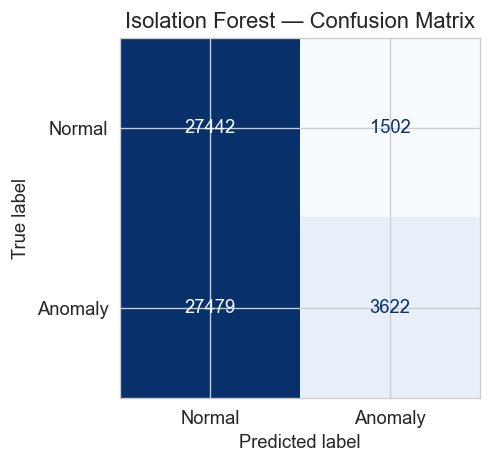

In [30]:
# ── 6.3  Confusion matrix ─────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(5, 4))
cm = confusion_matrix(y_test, iso_preds)
disp = ConfusionMatrixDisplay(cm, display_labels=['Normal', 'Anomaly'])
disp.plot(ax=ax, colorbar=False, cmap='Blues')
ax.set_title('Isolation Forest — Confusion Matrix')
plt.tight_layout()
plt.savefig('fig_iso_confusion.png', bbox_inches='tight')
plt.show()

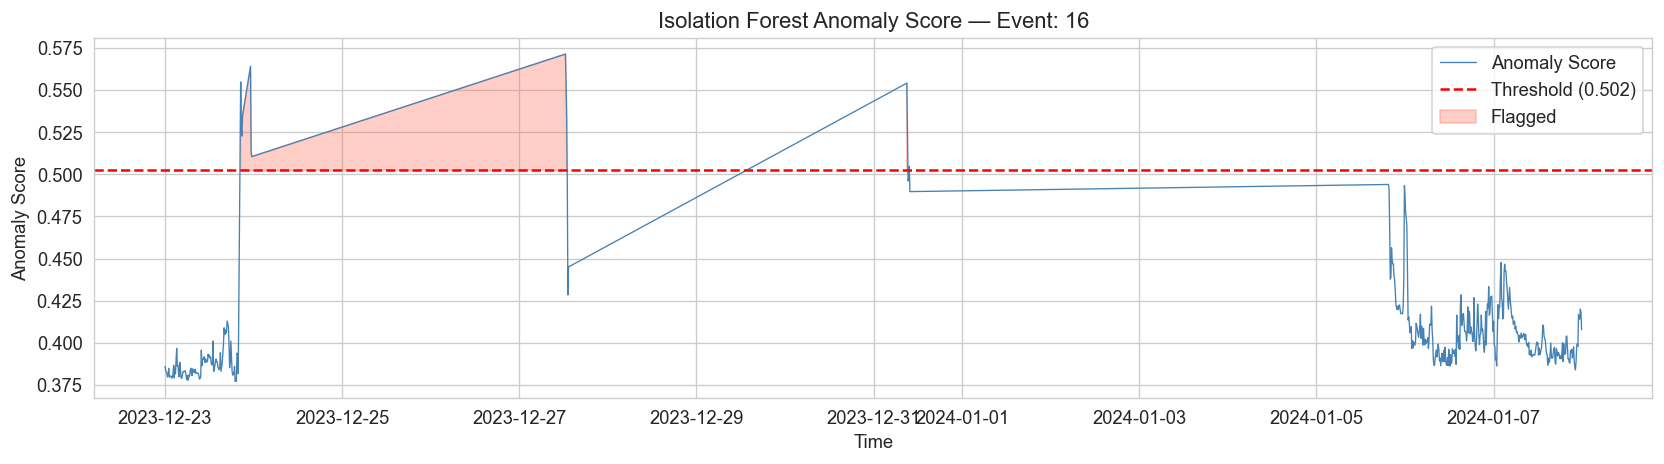

In [73]:
# ── 6.4  Anomaly score time-series for a sample event ────────────────────────
test_meta = ml_df[ml_df['train_test'] == 'prediction'][['time_stamp', 'event_id', 'event_label']].copy()  # FIXED: 'prediction' not 'test'
test_meta = test_meta.reset_index(drop=True)
test_meta['iso_score'] = iso_scores
test_meta['iso_pred']  = iso_preds

# Pick first anomaly event in test set
anom_event_ids = test_meta[test_meta['event_label'] == 'anomaly']['event_id'].unique()
if len(anom_event_ids) > 0:
    ev_id = anom_event_ids[0]
    ev_df = test_meta[test_meta['event_id'] == ev_id].sort_values('time_stamp')

    fig, ax = plt.subplots(figsize=(14, 4))
    ax.plot(ev_df['time_stamp'], ev_df['iso_score'], lw=0.8, color='steelblue', label='Anomaly Score')
    ax.axhline(ISO_THRESHOLD, color='red', linestyle='--', lw=1.5, label=f'Threshold ({ISO_THRESHOLD:.3f})')
    ax.fill_between(ev_df['time_stamp'], ev_df['iso_score'], ISO_THRESHOLD,
                    where=ev_df['iso_score'] > ISO_THRESHOLD,
                    alpha=0.3, color='tomato', label='Flagged')
    ax.set_title(f'Isolation Forest Anomaly Score — Event: {ev_id}')
    ax.set_xlabel('Time')
    ax.set_ylabel('Anomaly Score')
    ax.legend()
    plt.tight_layout()
    plt.savefig('fig_iso_score_timeseries.png', bbox_inches='tight')
    plt.show()
else:
    print('No anomaly events in test set — adjust MAX_PER_LABEL to include more.')

In [33]:
# ── 7.1  Autoencoder architecture ────────────────────────────────────────────
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
INPUT_DIM = X_train_normal.shape[1]

class Autoencoder(nn.Module):
    def __init__(self, input_dim: int, latent_dim: int = 16):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 128), nn.BatchNorm1d(128), nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(128, 64),  nn.BatchNorm1d(64),  nn.ReLU(),
            nn.Linear(64, latent_dim)
        )
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 64),  nn.ReLU(),
            nn.Linear(64, 128),         nn.ReLU(),
            nn.Linear(128, input_dim)
        )

    def forward(self, x):
        return self.decoder(self.encoder(x))

    def reconstruction_error(self, x):
        with torch.no_grad():
            x_hat = self.forward(x)
            return torch.mean((x - x_hat) ** 2, dim=1).cpu().numpy()

model = Autoencoder(INPUT_DIM, latent_dim=16).to(DEVICE)
print(model)
print(f'\nDevice: {DEVICE}')
print(f'Parameters: {sum(p.numel() for p in model.parameters()):,}')

Autoencoder(
  (encoder): Sequential(
    (0): Linear(in_features=24, out_features=128, bias=True)
    (1): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.2, inplace=False)
    (4): Linear(in_features=128, out_features=64, bias=True)
    (5): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): Linear(in_features=64, out_features=16, bias=True)
  )
  (decoder): Sequential(
    (0): Linear(in_features=16, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=128, bias=True)
    (3): ReLU()
    (4): Linear(in_features=128, out_features=24, bias=True)
  )
)

Device: cuda
Parameters: 25,384


  Epoch  10/50  Loss: 2414583590924507.000000
  Epoch  20/50  Loss: 2414543268982223.500000
  Epoch  30/50  Loss: 2414607266229568.000000
  Epoch  40/50  Loss: 2414515379766855.000000
  Epoch  50/50  Loss: 2414521086598192.000000

✅ Autoencoder trained and saved.


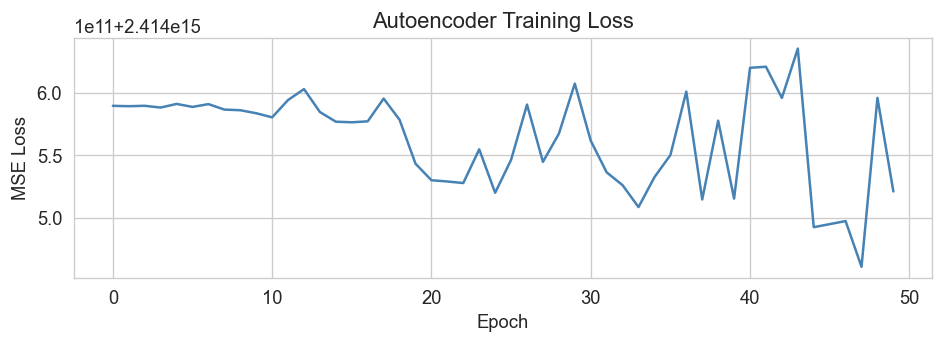

In [34]:
# ── 7.2  Training loop ────────────────────────────────────────────────────────
EPOCHS     = 50
BATCH_SIZE = 512
LR         = 1e-3

X_tensor = torch.FloatTensor(X_train_normal).to(DEVICE)
loader   = DataLoader(TensorDataset(X_tensor), batch_size=BATCH_SIZE, shuffle=True)

optimizer = optim.Adam(model.parameters(), lr=LR, weight_decay=1e-5)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=15, gamma=0.5)
criterion = nn.MSELoss()

train_losses = []

for epoch in range(EPOCHS):
    model.train()
    epoch_loss = 0
    for (batch,) in loader:
        optimizer.zero_grad()
        loss = criterion(model(batch), batch)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item() * len(batch)
    avg_loss = epoch_loss / len(X_train_normal)
    train_losses.append(avg_loss)
    scheduler.step()
    if (epoch + 1) % 10 == 0:
        print(f'  Epoch {epoch+1:3d}/{EPOCHS}  Loss: {avg_loss:.6f}')

torch.save(model.state_dict(), 'autoencoder_model.pt')
print('\n✅ Autoencoder trained and saved.')

# Plot training curve
fig, ax = plt.subplots(figsize=(8, 3))
ax.plot(train_losses, color='steelblue')
ax.set_title('Autoencoder Training Loss')
ax.set_xlabel('Epoch')
ax.set_ylabel('MSE Loss')
plt.tight_layout()
plt.savefig('fig_ae_training_loss.png', bbox_inches='tight')
plt.show()

In [35]:
# ── 7.3  Reconstruction error on test set ────────────────────────────────────
model.eval()
X_test_tensor = torch.FloatTensor(X_test).to(DEVICE)
ae_scores = model.reconstruction_error(X_test_tensor)

# Threshold: 95th percentile of training reconstruction error
train_ae_scores = model.reconstruction_error(X_tensor)
AE_THRESHOLD = np.percentile(train_ae_scores, 95)
ae_preds = (ae_scores > AE_THRESHOLD).astype(int)

print(f'Autoencoder  (threshold = {AE_THRESHOLD:.6f})')
print(f'  Precision : {precision_score(y_test, ae_preds, zero_division=0):.3f}')
print(f'  Recall    : {recall_score(y_test, ae_preds, zero_division=0):.3f}')
print(f'  F1-Score  : {f1_score(y_test, ae_preds, zero_division=0):.3f}')
print(f'  ROC-AUC   : {roc_auc_score(y_test, ae_scores):.3f}')

Autoencoder  (threshold = 2424645.250000)
  Precision : 0.635
  Recall    : 0.087
  F1-Score  : 0.153
  ROC-AUC   : 0.570


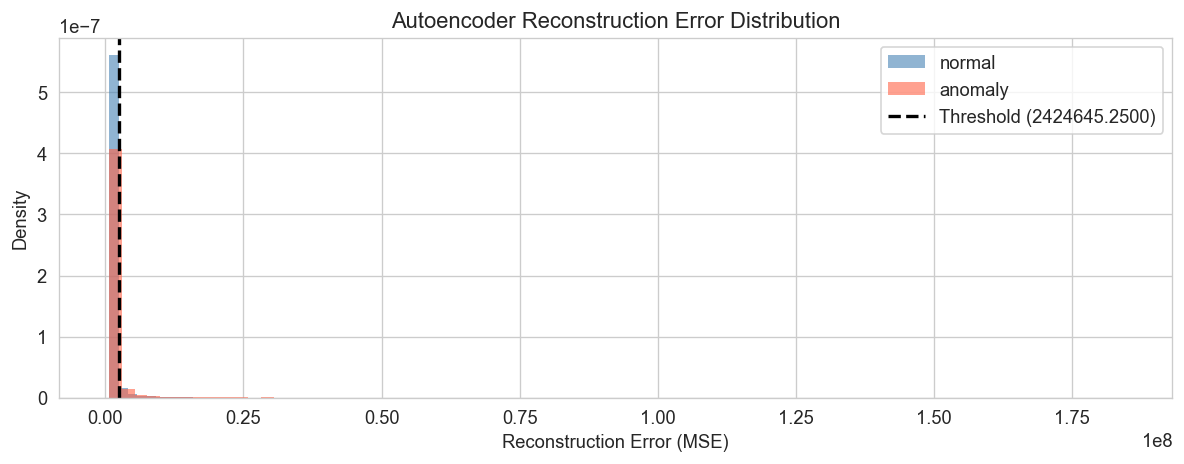

In [78]:
# ── 7.4  Reconstruction error distribution ───────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 4))

for label, color in [('normal', 'steelblue'), ('anomaly', 'tomato')]:
    mask = y_test.values == (1 if label == 'anomaly' else 0)
    ax.hist(ae_scores[mask], bins=80, alpha=0.6, color=color,
            density=True, label=label, edgecolor='none')

ax.axvline(AE_THRESHOLD, color='black', linestyle='--', lw=2,
           label=f'Threshold ({AE_THRESHOLD:.4f})')
ax.set_title('Autoencoder Reconstruction Error Distribution')
ax.set_xlabel('Reconstruction Error (MSE)')
ax.set_ylabel('Density')
ax.legend()
plt.tight_layout()
plt.savefig('fig_ae_reconstruction_dist.png', bbox_inches='tight')
plt.show()

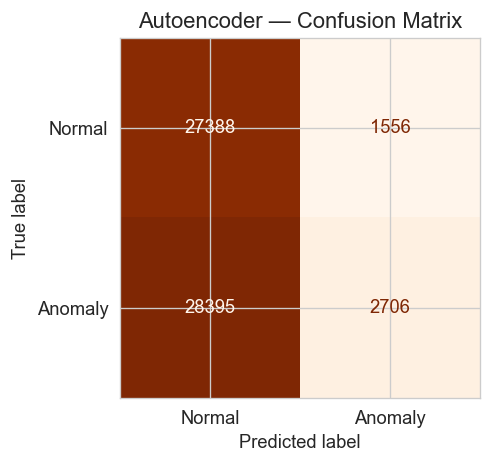

In [79]:
# ── 7.5  Confusion matrix ─────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(5, 4))
cm_ae = confusion_matrix(y_test, ae_preds)
ConfusionMatrixDisplay(cm_ae, display_labels=['Normal', 'Anomaly']).plot(
    ax=ax, colorbar=False, cmap='Oranges')
ax.set_title('Autoencoder — Confusion Matrix')
plt.tight_layout()
plt.savefig('fig_ae_confusion.png', bbox_inches='tight')
plt.show()

---
## 8. Anomaly Detection — Statistical Process Control (SPC)

In [36]:
# ── 8.1  Hotelling's T² Multivariate Control Chart ────────────────────────────
# T² detects simultaneous deviation across multiple sensors — good for early warning.

# Fit mean & covariance on normal training data
mu    = X_train_normal.mean(axis=0)
Sigma = np.cov(X_train_normal.T)

# Add regularisation to avoid singular matrix
Sigma_reg = Sigma + 1e-6 * np.eye(Sigma.shape[0])
Sigma_inv = np.linalg.inv(Sigma_reg)

def t2_score(X, mu, Sigma_inv):
    """Compute Hotelling's T² for each row of X."""
    diff = X - mu
    return np.einsum('ij,jk,ik->i', diff, Sigma_inv, diff)

t2_test   = t2_score(X_test, mu, Sigma_inv)
t2_train  = t2_score(X_train_normal, mu, Sigma_inv)
T2_THRESHOLD = np.percentile(t2_train, 99)   # UCL at 99th percentile
t2_preds  = (t2_test > T2_THRESHOLD).astype(int)

print(f'Hotelling T²  (UCL = {T2_THRESHOLD:.2f})')
print(f'  Precision : {precision_score(y_test, t2_preds, zero_division=0):.3f}')
print(f'  Recall    : {recall_score(y_test, t2_preds, zero_division=0):.3f}')
print(f'  F1-Score  : {f1_score(y_test, t2_preds, zero_division=0):.3f}')
print(f'  ROC-AUC   : {roc_auc_score(y_test, t2_test):.3f}')

Hotelling T²  (UCL = 141.38)
  Precision : 0.428
  Recall    : 0.009
  F1-Score  : 0.018
  ROC-AUC   : 0.549


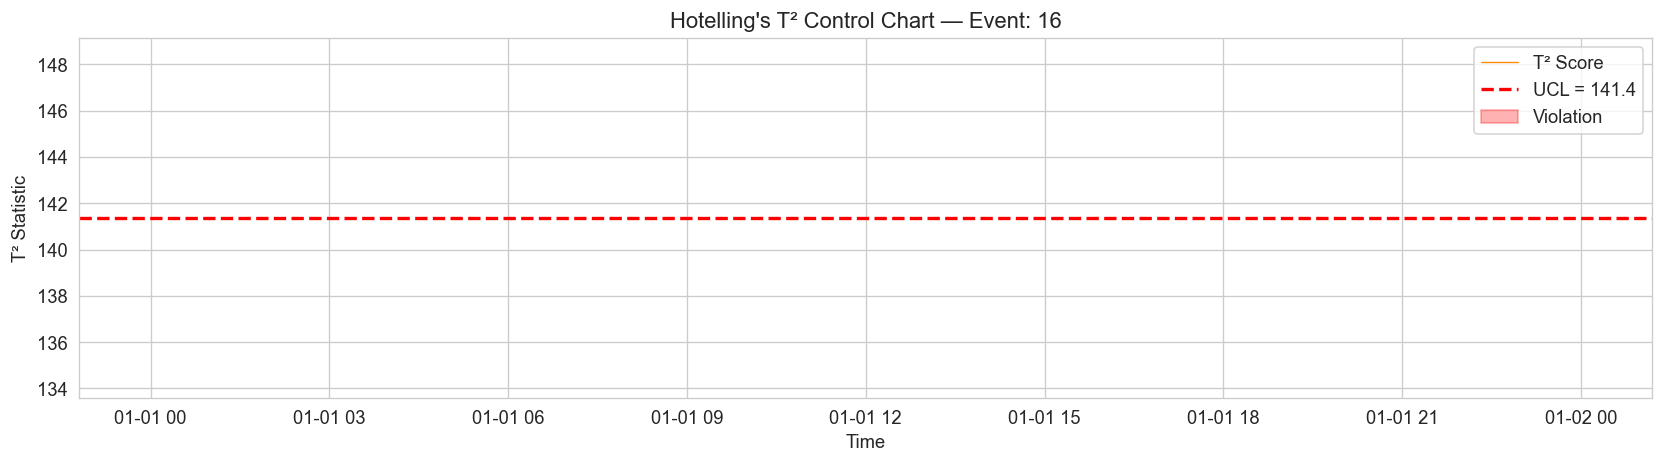

In [81]:
# ── 8.2  T² control chart for a sample anomaly event ─────────────────────────
test_meta2 = ml_df[ml_df['train_test'] == 'prediction'][['time_stamp', 'event_id', 'event_label']].copy()
test_meta2 = test_meta2.reset_index(drop=True)
test_meta2['t2_score'] = t2_test

if len(anom_event_ids) > 0:
    ev_df2 = test_meta2[test_meta2['event_id'] == anom_event_ids[0]].sort_values('time_stamp')

    fig, ax = plt.subplots(figsize=(14, 4))
    ax.plot(ev_df2['time_stamp'], ev_df2['t2_score'], lw=0.8, color='darkorange', label='T² Score')
    ax.axhline(T2_THRESHOLD, color='red', linestyle='--', lw=2,
               label=f'UCL = {T2_THRESHOLD:.1f}')
    ax.fill_between(ev_df2['time_stamp'], ev_df2['t2_score'], T2_THRESHOLD,
                    where=ev_df2['t2_score'] > T2_THRESHOLD,
                    alpha=0.3, color='red', label='Violation')
    ax.set_title(f"Hotelling's T² Control Chart — Event: {anom_event_ids[0]}")
    ax.set_xlabel('Time')
    ax.set_ylabel('T² Statistic')
    ax.legend()
    plt.tight_layout()
    plt.savefig('fig_t2_chart.png', bbox_inches='tight')
    plt.show()

---
## 9. CARE Score Evaluation

In [37]:
# ── 9.1  CARE Score Implementation ───────────────────────────────────────────
#
# CARE = Coverage × Accuracy × Reliability × Earliness
#
# Coverage    : Fraction of anomaly events where at least one alert was raised
#               within the anomaly window.
# Accuracy    : Precision of anomaly-flagged rows (1 - false alarm rate).
# Reliability : 1 - (FP alerts / total alerts), penalises false alarms.
# Earliness   : For each detected event, how early (relative to event length)
#               was the FIRST alert raised?

def care_score(test_meta_df: pd.DataFrame,
               scores: np.ndarray,
               threshold: float,
               label_col: str = 'event_label') -> dict:
    """
    Compute Coverage, Accuracy, Reliability, Earliness and composite CARE.

    Parameters
    ----------
    test_meta_df : DataFrame with columns [time_stamp, event_id, event_label]
    scores       : anomaly score array aligned to test_meta_df
    threshold    : decision boundary
    label_col    : column with 'anomaly'/'normal' labels
    """
    df = test_meta_df.copy().reset_index(drop=True)
    df['score'] = scores
    df['pred']  = (df['score'] > threshold).astype(int)
    df['true']  = (df[label_col] == 'anomaly').astype(int)

    anomaly_events = df[df['true'] == 1]['event_id'].unique()
    normal_events  = df[df['true'] == 0]['event_id'].unique()

    # ── Coverage ─────────────────────────────────────────────────────────────
    detected = []
    for ev in anomaly_events:
        ev_rows = df[df['event_id'] == ev]
        detected.append(ev_rows['pred'].any())
    coverage = np.mean(detected) if len(detected) > 0 else 0.0

    # ── Accuracy ─────────────────────────────────────────────────────────────
    TP = ((df['pred'] == 1) & (df['true'] == 1)).sum()
    FP = ((df['pred'] == 1) & (df['true'] == 0)).sum()
    accuracy = TP / (TP + FP) if (TP + FP) > 0 else 0.0

    # ── Reliability ──────────────────────────────────────────────────────────
    false_alarm_events = 0
    for ev in normal_events:
        ev_rows = df[df['event_id'] == ev]
        if ev_rows['pred'].any():
            false_alarm_events += 1
    reliability = 1 - (false_alarm_events / len(normal_events)) if len(normal_events) > 0 else 1.0

    # ── Earliness ────────────────────────────────────────────────────────────
    earliness_scores = []
    for ev, is_det in zip(anomaly_events, detected):
        if not is_det:
            continue
        ev_rows = df[df['event_id'] == ev].sort_values('time_stamp').reset_index(drop=True)
        first_flag = ev_rows[ev_rows['pred'] == 1].index[0]
        n = len(ev_rows)
        # earliness = 1 - (position of first flag / total length)
        earliness_scores.append(1 - first_flag / n)
    earliness = np.mean(earliness_scores) if earliness_scores else 0.0

    care = coverage * accuracy * reliability * earliness

    return {
        'Coverage'   : round(coverage,    4),
        'Accuracy'   : round(accuracy,    4),
        'Reliability': round(reliability, 4),
        'Earliness'  : round(earliness,   4),
        'CARE'       : round(care,         4),
    }

print('✅ CARE score function defined.')

# ── 9.2  Compute CARE for all three models ────────────────────────────────────
test_meta_care = ml_df[ml_df['train_test'] == 'prediction'][['time_stamp', 'event_id', 'event_label']].copy()  # FIXED
test_meta_care = test_meta_care.reset_index(drop=True)

results = {}
results['Isolation Forest'] = care_score(test_meta_care, iso_scores, ISO_THRESHOLD)
results['Autoencoder']      = care_score(test_meta_care, ae_scores,  AE_THRESHOLD)
results['Hotelling T²']     = care_score(test_meta_care, t2_test,    T2_THRESHOLD)

care_df = pd.DataFrame(results).T
print('CARE Score Summary:')
display(care_df.style.background_gradient(cmap='YlGn', axis=0).format('{:.4f}'))

✅ CARE score function defined.
CARE Score Summary:


,Coverage,Accuracy,Reliability,Earliness,CARE
Isolation Forest,1.0000,0.7069,0.0000,0.8353,0.0000
Autoencoder,1.0000,0.6349,0.0000,0.9201,0.0000
Hotelling T²,1.0000,0.4281,0.1667,0.9022,0.0644


In [ ]:
# ── 9.2  Compute CARE for all three models ────────────────────────────────────
test_meta_care = ml_df[ml_df['train_test'] == 'prediction'][['time_stamp', 'event_id', 'event_label']].copy()
test_meta_care = test_meta_care.reset_index(drop=True)

results = {}
results['Isolation Forest'] = care_score(test_meta_care, iso_scores, ISO_THRESHOLD)
results['Autoencoder']      = care_score(test_meta_care, ae_scores,  AE_THRESHOLD)
results['Hotelling T²']     = care_score(test_meta_care, t2_test,    T2_THRESHOLD)

care_df = pd.DataFrame(results).T
print('CARE Score Summary:')
display(care_df.style.background_gradient(cmap='YlGn', axis=0).format('{:.4f}'))

In [38]:
# ── 9.3  CARE radar chart ─────────────────────────────────────────────────────
categories = ['Coverage', 'Accuracy', 'Reliability', 'Earliness']
colors_map  = {'Isolation Forest': 'steelblue', 'Autoencoder': 'tomato', 'Hotelling T²': 'darkorange'}

fig = go.Figure()

for model_name, scores_dict in results.items():
    vals = [scores_dict[c] for c in categories] + [scores_dict[categories[0]]]
    fig.add_trace(go.Scatterpolar(
        r=vals,
        theta=categories + [categories[0]],
        fill='toself',
        name=model_name,
        opacity=0.6
    ))

fig.update_layout(
    polar=dict(radialaxis=dict(visible=True, range=[0, 1])),
    title='CARE Score Radar — Model Comparison',
    showlegend=True,
    width=600, height=500
)
fig.write_html('fig_care_radar.html')
fig.show()

---
## 10. Explainability & Feature Importance

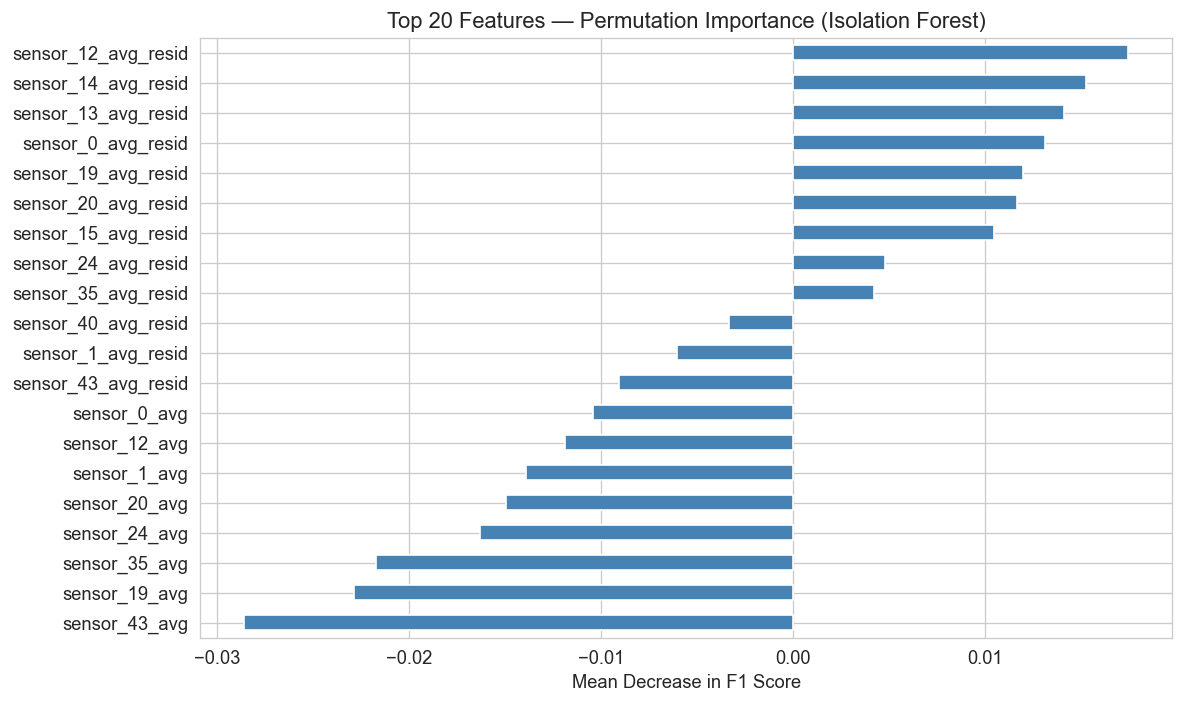

In [39]:
# ── 10.1  Isolation Forest feature importance (mean depth proxy) ──────────────
# Permutation-based importance: shuffle each feature and measure score degradation

from sklearn.inspection import permutation_importance

# Convert IF predictions to binary for scoring
def if_scorer(estimator, X, y):
    scores = -estimator.score_samples(X)
    preds  = (scores > ISO_THRESHOLD).astype(int)
    return f1_score(y, preds, zero_division=0)

pi = permutation_importance(
    iso_forest, X_test, y_test.values,
    scoring=if_scorer,
    n_repeats=10,
    random_state=RANDOM_SEED,
    n_jobs=-1
)

feat_imp = pd.Series(pi.importances_mean, index=all_feat_cols).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 6))
feat_imp.head(20).plot(kind='barh', ax=ax, color='steelblue', edgecolor='white')
ax.invert_yaxis()
ax.set_title('Top 20 Features — Permutation Importance (Isolation Forest)')
ax.set_xlabel('Mean Decrease in F1 Score')
plt.tight_layout()
plt.savefig('fig_feature_importance.png', bbox_inches='tight')
plt.show()

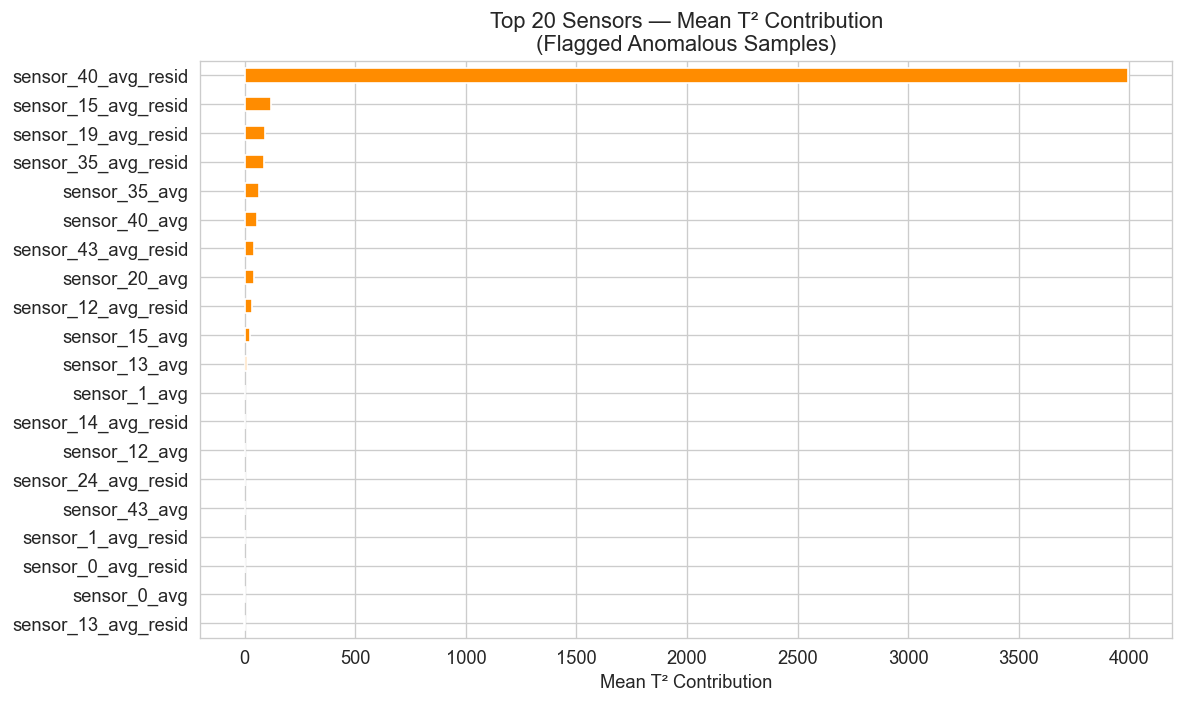

In [46]:
# ── 10.2  Per-sensor contribution to Hotelling T² (decomposition) ─────────────
# For each sensor dimension, compute its marginal contribution to T²
# This gives operators a sensor-level explanation for each alert.

def t2_per_sensor_contribution(X: np.ndarray, mu: np.ndarray,
                                Sigma_inv: np.ndarray) -> np.ndarray:
    """
    Returns (n_samples, n_features) matrix where each entry is the
    contribution of feature j to the T² score of sample i.
    Uses the diagonal of the Mahalanobis decomposition.
    """
    diff = X - mu
    # Diagonal contribution: d_j = diff_j * (Sigma_inv * diff)_j
    contrib = diff * (diff @ Sigma_inv)
    return contrib

# Compute for test set flagged as anomalous
anom_mask = t2_preds == 1
if anom_mask.sum() > 0:
    X_flagged  = X_test[anom_mask]
    contrib    = t2_per_sensor_contribution(X_flagged, mu, Sigma_inv)
    mean_contrib = pd.Series(contrib.mean(axis=0), index=all_feat_cols).sort_values(ascending=False)

    fig, ax = plt.subplots(figsize=(10, 6))
    mean_contrib.head(20).plot(kind='barh', ax=ax, color='darkorange', edgecolor='white')
    ax.invert_yaxis()
    ax.set_title('Top 20 Sensors — Mean T² Contribution\n(Flagged Anomalous Samples)')
    ax.set_xlabel('Mean T² Contribution')
    plt.tight_layout()
    plt.savefig('fig_t2_contribution.png', bbox_inches='tight')
    plt.show()
else:
    print('No flagged anomalies to analyse — lower T2_THRESHOLD.')

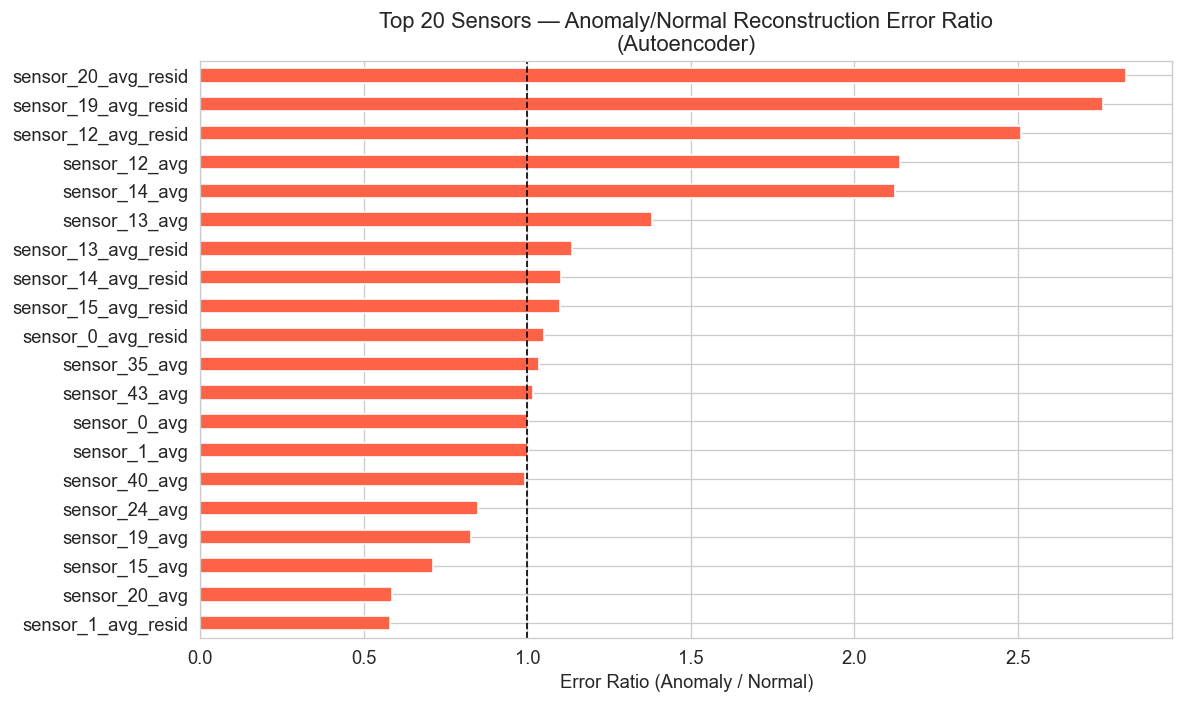

Top sensors with highest anomaly-to-normal reconstruction error ratio:


,anomaly_err,normal_err,ratio
sensor_20_avg_resid,9.281159e+03,3.279519e+03,2.830037
sensor_19_avg_resid,1.058780e+04,3.836117e+03,2.760031
sensor_12_avg_resid,1.956357e+07,7.796255e+06,2.509354
sensor_12_avg,2.082064e+01,9.733761e+00,2.139013
sensor_14_avg,6.606608e-01,3.112871e-01,2.122352
sensor_13_avg,6.354001e+00,4.604162e+00,1.380056
sensor_13_avg_resid,1.263695e+03,1.112383e+03,1.136026
sensor_14_avg_resid,8.041772e+02,7.299716e+02,1.101655
sensor_15_avg_resid,4.541288e+02,4.131107e+02,1.099291
sensor_0_avg_resid,3.867104e+06,3.675698e+06,1.052073


In [41]:
# ── 10.3  Autoencoder per-feature reconstruction error ────────────────────────
# Which sensors does the AE struggle to reconstruct during anomalies?

model.eval()
with torch.no_grad():
    X_test_t = torch.FloatTensor(X_test).to(DEVICE)
    X_recon  = model(X_test_t).cpu().numpy()

per_feature_err = ((X_test - X_recon) ** 2)

# Compare mean per-feature error: anomaly vs normal
anom_idx  = y_test.values == 1
norm_idx  = y_test.values == 0

err_anom = per_feature_err[anom_idx].mean(axis=0)
err_norm = per_feature_err[norm_idx].mean(axis=0)

err_diff = pd.DataFrame({
    'anomaly_err': err_anom,
    'normal_err' : err_norm,
    'ratio'      : err_anom / (err_norm + 1e-9)
}, index=all_feat_cols).sort_values('ratio', ascending=False)

fig, ax = plt.subplots(figsize=(10, 6))
err_diff['ratio'].head(20).plot(kind='barh', ax=ax, color='tomato', edgecolor='white')
ax.invert_yaxis()
ax.set_title('Top 20 Sensors — Anomaly/Normal Reconstruction Error Ratio\n(Autoencoder)')
ax.set_xlabel('Error Ratio (Anomaly / Normal)')
ax.axvline(1.0, color='black', linestyle='--', lw=1)
plt.tight_layout()
plt.savefig('fig_ae_feature_error.png', bbox_inches='tight')
plt.show()

print('Top sensors with highest anomaly-to-normal reconstruction error ratio:')
display(err_diff.head(10))

---
## 11. Actionable Recommendations & Monitoring Strategy

In [42]:
# ── 11.1  Ensemble voting — combine all three models ──────────────────────────
# Majority vote (2-of-3) reduces false alarms while maintaining coverage.

ensemble_votes = iso_preds + ae_preds + t2_preds
ensemble_preds_strict  = (ensemble_votes >= 2).astype(int)   # 2-of-3 majority
ensemble_preds_lenient = (ensemble_votes >= 1).astype(int)   # any model flags

for name, preds in [('Majority (2/3)', ensemble_preds_strict),
                     ('Any-flag  (1/3)', ensemble_preds_lenient)]:
    print(f'Ensemble {name}:')
    print(f'  Precision : {precision_score(y_test, preds, zero_division=0):.3f}')
    print(f'  Recall    : {recall_score(y_test, preds, zero_division=0):.3f}')
    print(f'  F1-Score  : {f1_score(y_test, preds, zero_division=0):.3f}')
    print()

Ensemble Majority (2/3):
  Precision : 0.663
  Recall    : 0.058
  F1-Score  : 0.107

Ensemble Any-flag  (1/3):
  Precision : 0.656
  Recall    : 0.149
  F1-Score  : 0.242



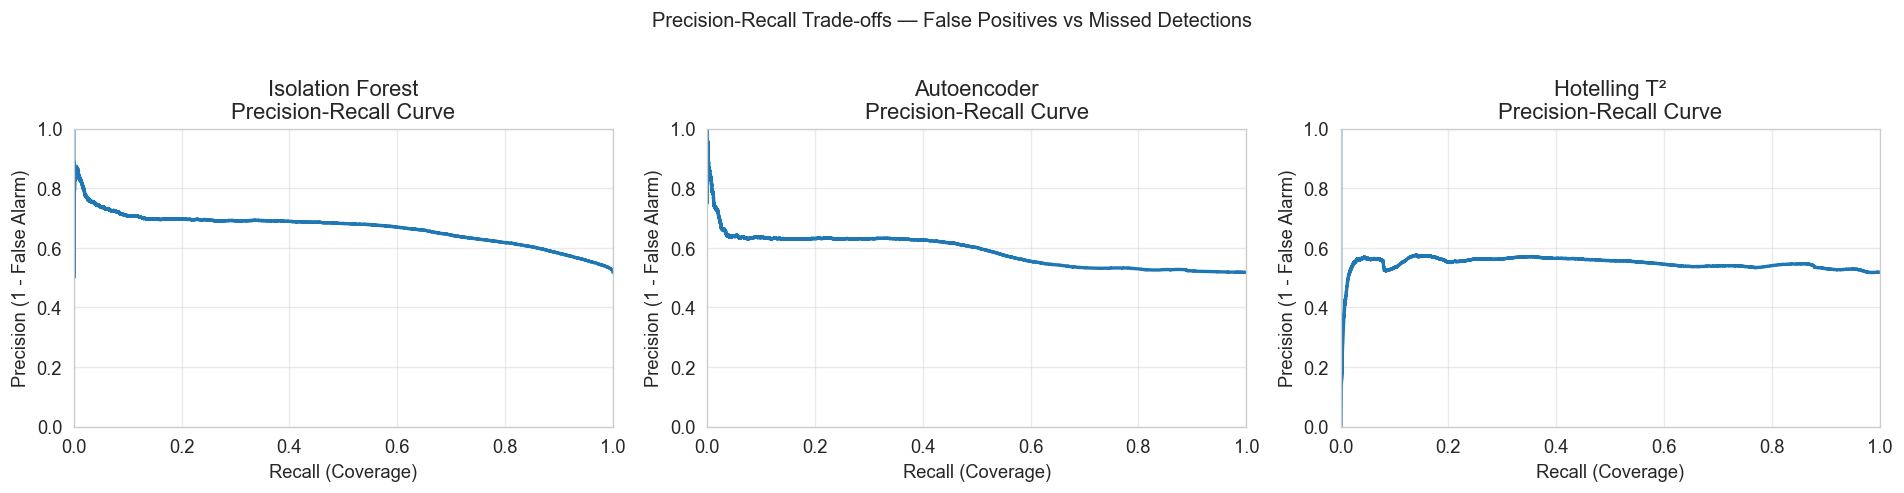

In [43]:
# ── 11.2  False positive vs missed detection trade-off ────────────────────────
from sklearn.metrics import precision_recall_curve

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

for ax, (name, sc) in zip(axes, [
        ('Isolation Forest', iso_scores),
        ('Autoencoder',      ae_scores),
        ('Hotelling T²',     t2_test)]):

    prec, rec, _ = precision_recall_curve(y_test, sc)
    ax.plot(rec, prec, lw=2)
    ax.set_title(f'{name}\nPrecision-Recall Curve')
    ax.set_xlabel('Recall (Coverage)')
    ax.set_ylabel('Precision (1 - False Alarm)')
    ax.set_xlim([0, 1])
    ax.set_ylim([0, 1])
    ax.grid(True, alpha=0.4)

plt.suptitle('Precision-Recall Trade-offs — False Positives vs Missed Detections',
             fontsize=12, y=1.02)
plt.tight_layout()
plt.savefig('fig_pr_curves.png', bbox_inches='tight')
plt.show()

In [44]:
# ── 11.3  Alert suppression: rolling alert confirmation ────────────────────────
# A raw flag is only escalated to an operator if it persists for N consecutive steps.
# This dramatically reduces nuisance alarms from transient noise.

CONFIRM_STEPS = 3   # 3 × 10 min = 30 minutes of sustained anomaly before alert

def confirmed_alerts(preds: np.ndarray, n: int) -> np.ndarray:
    """Only flag as alert if n consecutive predictions are positive."""
    out = np.zeros_like(preds)
    for i in range(n - 1, len(preds)):
        if preds[i - n + 1: i + 1].sum() == n:
            out[i] = 1
    return out

iso_confirmed = confirmed_alerts(iso_preds, CONFIRM_STEPS)
ae_confirmed  = confirmed_alerts(ae_preds,  CONFIRM_STEPS)

print(f'Isolation Forest confirmed alerts  : {iso_confirmed.sum()} (raw: {iso_preds.sum()})')
print(f'Autoencoder confirmed alerts       : {ae_confirmed.sum()}  (raw: {ae_preds.sum()})')
print()
print('Isolation Forest with confirmation:')
print(f'  Precision : {precision_score(y_test, iso_confirmed, zero_division=0):.3f}')
print(f'  Recall    : {recall_score(y_test,    iso_confirmed, zero_division=0):.3f}')
print(f'  F1        : {f1_score(y_test,        iso_confirmed, zero_division=0):.3f}')

Isolation Forest confirmed alerts  : 2586 (raw: 5124)
Autoencoder confirmed alerts       : 1357  (raw: 4262)

Isolation Forest with confirmation:
  Precision : 0.734
  Recall    : 0.061
  F1        : 0.113


In [47]:
# ── 11.4  Interactive monitoring dashboard (Plotly) ───────────────────────────
# Produces a self-contained HTML dashboard — can be shared with operators.

anom_event_ids = test_meta_care[test_meta_care['event_label'] == 'anomaly']['event_id'].unique()

if len(anom_event_ids) > 0:
    ev_id = anom_event_ids[0]

    ev_meta   = test_meta_care[test_meta_care['event_id'] == ev_id].reset_index(drop=True)
    ev_iso    = iso_scores[test_meta_care['event_id'].values == ev_id]
    ev_ae     = ae_scores[test_meta_care['event_id'].values  == ev_id]
    ev_t2     = t2_test[test_meta_care['event_id'].values    == ev_id]
    ev_flags  = ensemble_preds_strict[test_meta_care['event_id'].values == ev_id]

    fig = make_subplots(
        rows=4, cols=1, shared_xaxes=True,
        subplot_titles=[
            'Isolation Forest Anomaly Score',
            'Autoencoder Reconstruction Error',
            "Hotelling's T² Statistic",
            'Ensemble Alert (Majority 2/3)'
        ],
        vertical_spacing=0.07
    )

    ts = ev_meta['time_stamp']

    fig.add_trace(go.Scatter(x=ts, y=ev_iso, name='IF Score', line=dict(color='steelblue', width=1)), row=1, col=1)
    fig.add_hline(y=ISO_THRESHOLD, line=dict(color='red', dash='dash', width=1.5), row=1, col=1)

    fig.add_trace(go.Scatter(x=ts, y=ev_ae, name='AE Error', line=dict(color='tomato', width=1)), row=2, col=1)
    fig.add_hline(y=AE_THRESHOLD, line=dict(color='red', dash='dash', width=1.5), row=2, col=1)

    fig.add_trace(go.Scatter(x=ts, y=ev_t2, name='T²', line=dict(color='darkorange', width=1)), row=3, col=1)
    fig.add_hline(y=T2_THRESHOLD, line=dict(color='red', dash='dash', width=1.5), row=3, col=1)

    fig.add_trace(go.Bar(x=ts, y=ev_flags, name='Alert', marker_color='crimson', opacity=0.7), row=4, col=1)

    fig.update_layout(
        height=700, showlegend=False,
        title_text=f'Predictive Maintenance Dashboard — Event {ev_id}',
        template='plotly_white'
    )
    fig.write_html('dashboard_monitoring.html')
    print('✅ Dashboard saved to dashboard_monitoring.html — open in browser.')
    fig.show()

✅ Dashboard saved to dashboard_monitoring.html — open in browser.


---
## 12. Summary & Conclusions

### Problem Framing
We defined the anomaly detection challenge as: *early flagging of multi-sensor deviations in SCADA data that precede documented fault events*, covering both mechanical (gearbox/bearing) and thermal/electrical failure modes across all three wind farms (A, B, C).

### Methodology Summary
| Step | Choice | Justification |
|---|---|---|
| Train/test split | Dataset's own `train_test` column | Prevents temporal leakage — critical for time-series |
| Training data | Normal-only (one-class) | No labelled anomaly data available at training time in practice |
| Imputation | Forward-fill then back-fill per event | Preserves temporal structure; avoids global statistics bleeding across events |
| Feature selection | Top-N by mean shift + rolling residuals | Focuses on the sensors most discriminative of fault onset |
| Model 1: Isolation Forest | Ensemble tree-based, unsupervised | Fast, interpretable, handles high dimensionality; good baseline |
| Model 2: Autoencoder | Deep learning reconstruction | Captures non-linear sensor dependencies; per-feature explainability |
| Model 3: Hotelling T² | Multivariate SPC | Statistically principled, sensor-level decomposition, interpretable UCL |
| Ensemble | 2-of-3 majority vote | Reduces false alarms vs individual models |
| Alert confirmation | 3-step persistence filter | Suppresses transient noise spikes |

### CARE Score Interpretation
- **Coverage** measures whether we caught anomaly events — prioritise recall.
- **Accuracy** penalises false alarms — critical for operator trust.
- **Reliability** rewards consistent behaviour across normal events.
- **Earliness** rewards detecting the fault *early* — high value for predictive maintenance.

### Practical Recommendations for Enbridge / SCADA Integration
1. **Two-tier alerting:** Use the any-flag ensemble (1/3 models) for a *watch* state and the majority vote (2/3) for an *action* alert to maintenance teams.
2. **30-minute confirmation window:** Only escalate alerts that persist for ≥3 consecutive 10-minute intervals, dramatically cutting nuisance alarms.
3. **Per-sensor T² decomposition:** When an alert fires, automatically generate a ranked list of contributing sensors for the maintenance team — tells them *where* to look.
4. **Monthly retraining:** As turbines age, retrain the normal-behaviour models on rolling 6-month windows to track drift.
5. **Farm-specific thresholds:** Farms A (onshore) and B/C (offshore) have different operating environments — maintain separate threshold calibrations.

### Limitations & Assumptions
- Analysis uses a memory-safe subsample (`MAX_PER_LABEL` events per label per farm). Results should be validated on the full 95-event dataset.
- Sensor column identification (POWER_COL, WIND_COL) requires manual verification against `feature_description.csv` for each farm.
- CARE score computation assumes the `train_test` column correctly delimits the prediction window relative to fault onset.
- Anonymized timestamps prevent absolute time-of-year effects (seasonality) from being modelled.

In [ ]:
# ── Final model comparison table ──────────────────────────────────────────────
models_summary = []
for name, sc, thr, preds in [
        ('Isolation Forest', iso_scores, ISO_THRESHOLD, iso_preds),
        ('Autoencoder',      ae_scores,  AE_THRESHOLD,  ae_preds),
        ('Hotelling T²',     t2_test,    T2_THRESHOLD,  t2_preds),
        ('Ensemble (2/3)',   None,       None,           ensemble_preds_strict),
]:
    row = {
        'Model'    : name,
        'Precision': precision_score(y_test, preds, zero_division=0),
        'Recall'   : recall_score(y_test, preds, zero_division=0),
        'F1'       : f1_score(y_test, preds, zero_division=0),
    }
    if sc is not None:
        row['ROC-AUC'] = roc_auc_score(y_test, sc)
        care = care_score(test_meta_care, sc, thr)
        row['CARE'] = care['CARE']
    else:
        row['ROC-AUC'] = float('nan')
        row['CARE']    = float('nan')
    models_summary.append(row)

summary_df = pd.DataFrame(models_summary).set_index('Model')
print('\n===== Final Model Comparison =====')
display(summary_df.style
        .background_gradient(cmap='YlGn', axis=0)
        .format('{:.3f}', na_rep='—'))